# IBM HR Analytics Employee Attrition Analysis

## Data Analysis Project

**Course:** Data Analysis

**Dataset:** IBM HR Analytics Employee Attrition & Performance

**Prepared by:** Ahmed Sameh Mohamed Zaky

---

### Project Goal

The purpose of this project is to analyze employee attrition using IBM HR Analytics data. The analysis follows a complete business-oriented data analysis workflow, starting from understanding the business problem through data preparation, exploratory data analysis, feature engineering, and ending with actionable business recommendations for HR management.

# Business Problem

IBM has experienced an increasing employee attrition rate. Employee turnover increases recruitment costs, reduces productivity, and negatively impacts organizational performance.

The Human Resources department wants to understand the factors that contribute to employee attrition and identify employee groups that are most likely to leave the company.

The final goal is to generate data-driven recommendations that improve employee retention and support strategic HR decision-making.

# Business Objectives

The main objectives of this analysis are:

- Understand employee attrition patterns.
- Identify the main factors affecting employee turnover.
- Discover relationships between employee characteristics and attrition.
- Generate meaningful business insights.
- Recommend practical strategies to improve employee retention.

## Target Variable

The target variable is **Attrition**.

This variable indicates whether an employee has left the company ("Yes") or remained with the company ("No").

Throughout the analysis, all business questions and insights will ultimately relate back to this variable.

## Business Questions

This analysis aims to answer several important business questions, including:

- Which employees are more likely to leave the company?
- Does overtime increase employee attrition?
- Does monthly income affect employee retention?
- Which departments experience the highest attrition?
- Does job satisfaction influence employee turnover?
- Which employee groups should HR focus on to improve retention?

Additional business questions may be explored during the analysis whenever appropriate.

## Analysis Workflow

This project follows a structured end-to-end data analysis workflow:

1. **Phase 1 — Business Understanding**
2. **Phase 2 — Dataset Understanding**
3. **Phase 3 — Data Quality Assessment**
4. **Phase 4 — Data Cleaning**
5. **Phase 5 — Feature Preparation**
6. **Phase 6 — End-to-End EDA, Feature Engineering, Interpretation, Insights, and Recommendations**
7. **Phase 7 — Executive Summary**
8. **Phase 8 — Final Business Report**

Encoding and scaling are retained in **Appendix A** because they are mainly required for optional machine-learning preparation, while the business EDA uses readable categories and original units.


In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Phase 2: Dataset Understanding

## Why Are We Doing This?

Before assessing data quality or performing any analysis, we need to understand the structure of the dataset.

This includes identifying the number of observations, available features, data types, and the overall characteristics of the data.

Understanding the dataset helps us determine what information is available and prepares us for the data quality assessment in the next phase.

## Load the Dataset

The first step is to load the dataset into a pandas DataFrame so it can be explored and analyzed.

In [189]:
# Load the dataset using a portable path
from pathlib import Path

#read_data
df=pd.read_csv("C:\\Users\\soham\\Desktop\\ahmed\\NTI-ML\\Employee\\Data\\employee_attrition_course.csv")

## Dataset Dimensions

Understanding the size of the dataset helps estimate the amount of available information.

Here, we check the number of rows (employees) and columns (features).

In [190]:
# Display dataset dimensions
rows, columns = df.shape

print(f"Number of Rows: {rows}")
print(f"Number of Columns: {columns}")

Number of Rows: 1495
Number of Columns: 37


## Preview the Dataset

Before performing any analysis, it is helpful to inspect a few records to understand how the data is organized and what each feature represents.

In [191]:
# Display the first five rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,RecordID,ManagerNotes
0,41.0,Yes,Travel_Rarely,1102,sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,NaN,19479,8,Y,Yes,11,3,1,80,0,8.0,0,1,6.0,4,0,5,100001,NaN
1,49.0,No,Travel_Frequently,279,Research and Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,NaN,24907,1,Y,No,23,4,4,80,1,10.0,3,3,10.0,7,1,7,100002,NaN
2,37.0,Yes,Travel_Rarely,1373,Research and Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090.0,2396,6,Y,Yes,15,3,2,80,0,7.0,3,3,0.0,0,0,0,100003,Needs Improvement
3,33.0,No,Travel_Frequently,1392,Research and Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909.0,23159,1,Y,Yes,11,3,3,80,0,8.0,3,3,NaN,7,3,0,100004,Average
4,27.0,No,Travel_Rarely,591,Research and Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468.0,16632,9,Y,No,12,3,4,80,1,6.0,3,3,2.0,2,2,2,100005,NaN


## Dataset Information

Next, we inspect the overall structure of the dataset, including column names, data types, and missing values.

This provides a quick overview before performing a detailed data quality assessment.

In [192]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1451 non-null   float64
 1   Attrition                 1495 non-null   str    
 2   BusinessTravel            1495 non-null   str    
 3   DailyRate                 1495 non-null   int64  
 4   Department                1495 non-null   str    
 5   DistanceFromHome          1495 non-null   int64  
 6   Education                 1495 non-null   int64  
 7   EducationField            1466 non-null   str    
 8   EmployeeCount             1495 non-null   int64  
 9   EmployeeNumber            1495 non-null   int64  
 10  EnvironmentSatisfaction   1495 non-null   int64  
 11  Gender                    1495 non-null   str    
 12  HourlyRate                1495 non-null   int64  
 13  JobInvolvement            1495 non-null   int64  
 14  JobLevel           

## Numerical Features Summary

Summary statistics provide an overview of the numerical variables, including their central tendency and spread.

This helps identify unusual values that may require further investigation later.

In [193]:
# Summary statistics for numerical features
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,RecordID
count,1451.000000,1495.000000,1495.000000,1495.000000,1495.0,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1375.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.0,1495.000000,1434.000000,1495.000000,1495.000000,1420.000000,1495.000000,1495.000000,1495.000000,1495.000000
mean,36.973122,800.762542,9.442140,2.915050,1.0,1027.762542,2.730435,65.882943,2.728428,2.063545,2.725084,7717.508364,14261.773244,2.691639,15.202676,3.154515,2.711037,80.0,0.790635,11.273361,2.800000,2.761873,7.065493,4.230100,2.199331,4.125753,100739.142475
std,9.229636,403.789611,9.590084,1.026494,0.0,601.875560,1.091640,20.350715,0.709348,1.110062,1.101906,21151.885011,7108.869434,2.494015,3.658222,0.361563,1.081414,0.0,0.848445,7.833083,1.286112,0.707214,6.200031,3.616196,3.226667,3.563383,424.837215
min,16.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,100001.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,493.500000,2.000000,48.000000,2.000000,1.000000,2.000000,2935.500000,8012.500000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,100371.000000
50%,36.000000,798.000000,7.000000,3.000000,1.0,1025.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4941.000000,14120.000000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,100740.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1556.500000,4.000000,84.000000,3.000000,3.000000,4.000000,8468.500000,20435.000000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,101107.500000
max,78.000000,1499.000000,150.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,500000.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,101470.000000


## Categorical Features Summary

Categorical features describe employee characteristics such as department, gender, and job role.

Reviewing these features helps us understand the available categories before performing detailed analysis.

In [194]:
# Summary statistics for categorical features
df.describe(include="object")

C:\Users\soham\AppData\Local\Temp\ipykernel_21144\3721300397.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime,ManagerNotes
count,1495,1495,1495,1466,1495,1480,1495,1495,1495,598
unique,2,7,3,6,4,12,3,1,2,3
top,No,Travel_Rarely,Research and Development,Life Sciences,Male,Sales Executive,Married,Y,No,Good
freq,1256,1051,973,605,878,321,690,1495,1070,211


## Feature Classification

Before assessing data quality, we classify the dataset into numerical and categorical features.

This classification will guide the appropriate analysis and visualization techniques used throughout the project.

In [195]:
# Select numerical columns
numerical_columns = df.select_dtypes(include="number").columns

# Select categorical columns
categorical_columns = df.select_dtypes(include="object").columns

print(f"Numerical Features: {len(numerical_columns)}")
print(numerical_columns.tolist())

print("\nCategorical Features:", len(categorical_columns))
print(categorical_columns.tolist())

Numerical Features: 27
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'RecordID']

Categorical Features: 10
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime', 'ManagerNotes']


C:\Users\soham\AppData\Local\Temp\ipykernel_21144\71043729.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


## Phase Summary

At this stage, we have gained a clear understanding of the dataset's structure, features, and overall characteristics.

No modifications have been made to the data yet.

In the next phase, we will assess the quality of the dataset by identifying missing values, duplicate records, invalid values, inconsistent values, constant features, and potential outliers before making any cleaning decisions.

___
### Phase 3: Data Quality Assessment

3.1 Missing Values

3.2 Duplicate Records

3.3 Duplicate IDs

3.4 Data Types Validation

3.5 Inconsistent Values

3.6 Invalid Values

3.7 Constant Features

3.8 Outlier Assessment

3.9 Data Quality Dashboard

3.10 Data Cleaning Decision Log

___
## 3.1 Missing Values

### Why Are We Checking Missing Values?

Missing values are one of the most common data quality issues.

They may reduce the reliability of the analysis, introduce bias, or affect statistical calculations if left untreated.

In this step, we identify the number and percentage of missing values in each feature before deciding how they should be handled.

In [196]:
# Count missing values
missing_count = df.isnull().sum()

# Calculate missing percentage
missing_percentage = (df.isnull().mean() * 100).round(2)

# Create summary table
missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage (%)": missing_percentage
})

# Show columns with missing values only
missing_summary[missing_summary["Missing Values"] > 0].sort_values(
    by="Missing Percentage (%)",
    ascending=False
)

,Missing Values,Missing Percentage (%)
ManagerNotes,897,60.00
MonthlyIncome,120,8.03
YearsAtCompany,75,5.02
TotalWorkingYears,61,4.08
Age,44,2.94
EducationField,29,1.94
JobRole,15,1.00


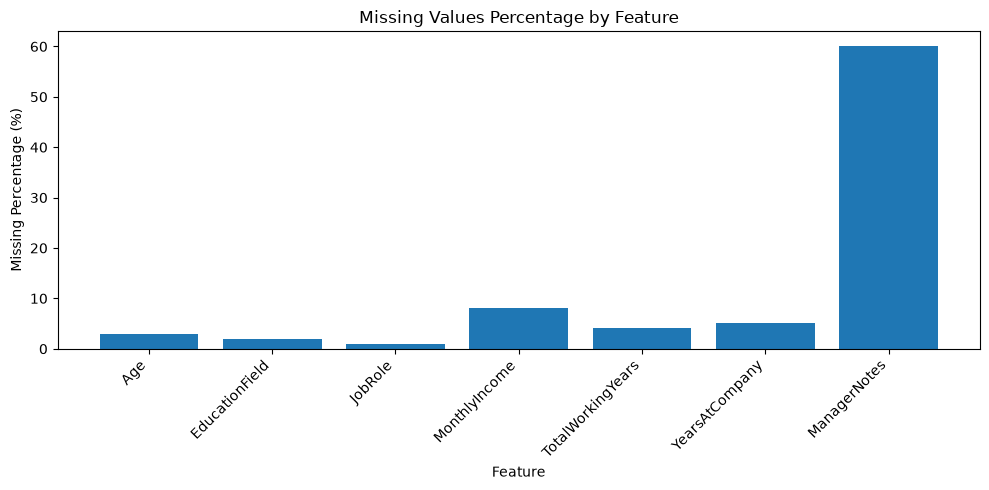

In [197]:
# Plot missing value percentages
missing_plot = (
    missing_summary[missing_summary["Missing Values"] > 0]
    .reset_index()
    .rename(columns={"index": "Feature"})
)

plt.figure(figsize=(10, 5))
plt.bar(
    missing_plot["Feature"],
    missing_plot["Missing Percentage (%)"]
)
plt.title("Missing Values Percentage by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3.2 Duplicate Records

### Why Are We Checking Duplicate Records?

Duplicate records represent repeated observations of the same employee.

If duplicate rows exist, they can bias statistical analysis, distort visualizations, and lead to inaccurate business insights.

In this step, we identify duplicate records before deciding whether they should be removed.

In [198]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_count}")

Duplicate Rows: 25


In [199]:
# Display duplicate rows
duplicates = df[df.duplicated()]

duplicates.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,RecordID,ManagerNotes
1470,32.0,No,Travel_Frequently,116,Research and Development,13,3,Other,1,1234,3,Female,77,2,1,Laboratory Technician,2,Married,2743.0,7331,1,Y,No,20,4,3,80,1,2.0,2,3,2.0,2,2,2,100881,NaN
1471,53.0,No,Travel_Rarely,1436,sales,6,2,Marketing,1,205,2,Male,34,3,2,Sales Representative,3,Married,NaN,16047,2,Y,Yes,20,4,4,80,1,13.0,3,1,7.0,7,4,5,100153,Needs Improvement
1472,39.0,No,Travel_Rarely,613,Research and Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991.0,21457,4,Y,No,15,3,1,80,1,9.0,5,3,7.0,7,1,7,101467,NaN
1473,34.0,No,Travel_Rarely,971,sales,1,3,Technical Degree,1,1535,4,Male,64,2,3,Sales Executive,3,Married,7083.0,12288,1,Y,Yes,14,3,4,80,0,10.0,3,3,10.0,9,8,6,101085,NaN
1474,50.0,No,Travel_Frequently,333,Research and Development,22,5,Medical,1,1539,3,Male,88,1,4,Research Director,4,Single,14411.0,24450,1,Y,Yes,13,3,4,80,0,32.0,2,3,32.0,6,13,9,101087,NaN


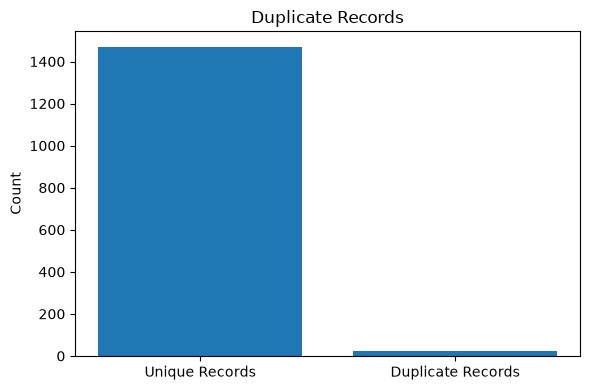

In [200]:
# Create duplicate summary
duplicate_summary = pd.DataFrame({
    "Status": ["Unique Records", "Duplicate Records"],
    "Count": [len(df) - duplicate_count, duplicate_count]
})

plt.figure(figsize=(6, 4))
plt.bar(duplicate_summary["Status"], duplicate_summary["Count"])
plt.title("Duplicate Records")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 3.3 Duplicate Employee IDs

### Why Are We Checking Duplicate IDs?

Each employee should have a unique identifier.

If the same employee ID appears more than once, it may indicate duplicated employee records, data entry errors, or inconsistencies in the dataset.

In this step, we verify that every employee has a unique identifier before proceeding with the analysis.

In [201]:
# Check for duplicate employee IDs
duplicate_employee_ids = df["EmployeeNumber"].duplicated().sum()

print(f"Duplicate Employee IDs: {duplicate_employee_ids}")

Duplicate Employee IDs: 25


In [202]:
# Display duplicated employee IDs
duplicate_ids = df[df["EmployeeNumber"].duplicated(keep=False)]

duplicate_ids.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,RecordID,ManagerNotes
57,35.0,No,Travel_Rarely,1142,Research and Development,23,4,Medical,1,75,3,Female,30,3,1,Laboratory Technician,1,Married,NaN,16002,3,Y,Yes,15,3,3,80,1,4.0,3,3,2.0,2,2,2,100058,NaN
134,26.0,No,Travel_Rarely,1355,Human Resourses,25,1,Life Sciences,1,177,3,Female,61,3,1,Human Resources,3,Married,2942.0,8916,1,Y,No,23,4,4,80,1,8.0,3,3,8.0,7,5,7,100135,NaN
152,53.0,No,Travel_Rarely,1436,sales,6,2,Marketing,1,205,2,Male,34,3,2,Sales Representative,3,Married,NaN,16047,2,Y,Yes,20,4,4,80,1,13.0,3,1,7.0,7,4,5,100153,Needs Improvement
207,36.0,No,Travel_Frequently,635,Research and Development,18,1,Medical,1,286,2,Female,73,3,1,Laboratory Technician,4,Single,2153.0,7703,1,Y,No,13,3,1,80,0,8.0,2,3,8.0,1,1,7,100208,Good
562,33.0,Yes,Travel_Rarely,527,Research and Development,1,4,Other,1,780,4,Male,63,3,1,Research Scientist,4,Single,2686.0,5207,1,Y,Yes,13,3,3,80,0,10.0,2,2,10.0,9,7,8,100563,Good


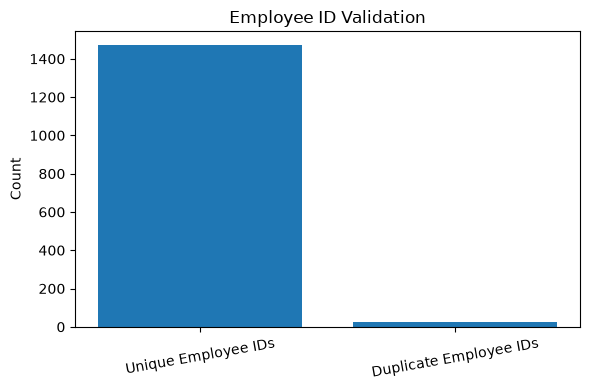

In [203]:
# Create Employee ID summary
employee_id_summary = pd.DataFrame({
    "Status": ["Unique Employee IDs", "Duplicate Employee IDs"],
    "Count": [
        df["EmployeeNumber"].nunique(),
        duplicate_employee_ids
    ]
})

plt.figure(figsize=(6, 4))
plt.bar(employee_id_summary["Status"], employee_id_summary["Count"])
plt.title("Employee ID Validation")
plt.ylabel("Count")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## 3.4 Data Types Validation

### Why Are We Checking Data Types?

Each feature should have the appropriate data type based on its business meaning.

Incorrect data types can lead to inaccurate calculations, incorrect visualizations, and errors during data preprocessing.

In this step, we verify that every feature has the correct data type before continuing with the analysis.

In [204]:
# Display the data type of each feature
data_types = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.values
})

data_types

,Feature,Data Type
0,Age,float64
1,Attrition,str
2,BusinessTravel,str
3,DailyRate,int64
4,Department,str
5,DistanceFromHome,int64
6,Education,int64
7,EducationField,str
8,EmployeeCount,int64
9,EmployeeNumber,int64


In [205]:
# Count each data type
df.dtypes.value_counts()

int64      23
str        10
float64     4
Name: count, dtype: int64

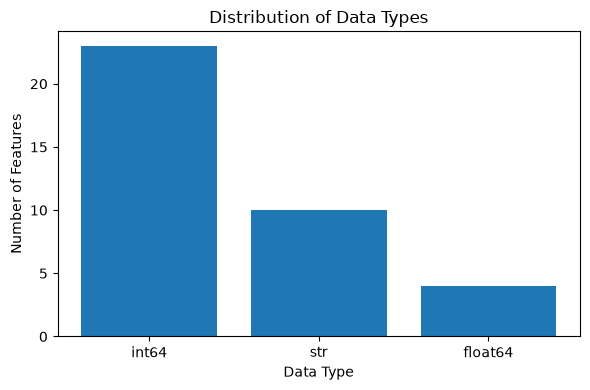

In [206]:
# Count and plot data types
dtype_counts = df.dtypes.astype(str).value_counts()

plt.figure(figsize=(6, 4))
plt.bar(dtype_counts.index, dtype_counts.values)
plt.title("Distribution of Data Types")
plt.xlabel("Data Type")
plt.ylabel("Number of Features")
plt.tight_layout()
plt.show()

# Phase 3.5 Feature Evaluation & Cleaning Strategy

## Why Are We Doing This Step?

Before modifying the dataset, it is important to evaluate the features from both statistical and business perspectives.

Some features may contain a high percentage of missing values, while others may be highly correlated with similar features.

Instead of cleaning every feature blindly, we first determine:

- Which features should be kept.
- Which features may be removed.
- Which features require special handling.

This helps reduce unnecessary preprocessing and preserves meaningful business information.

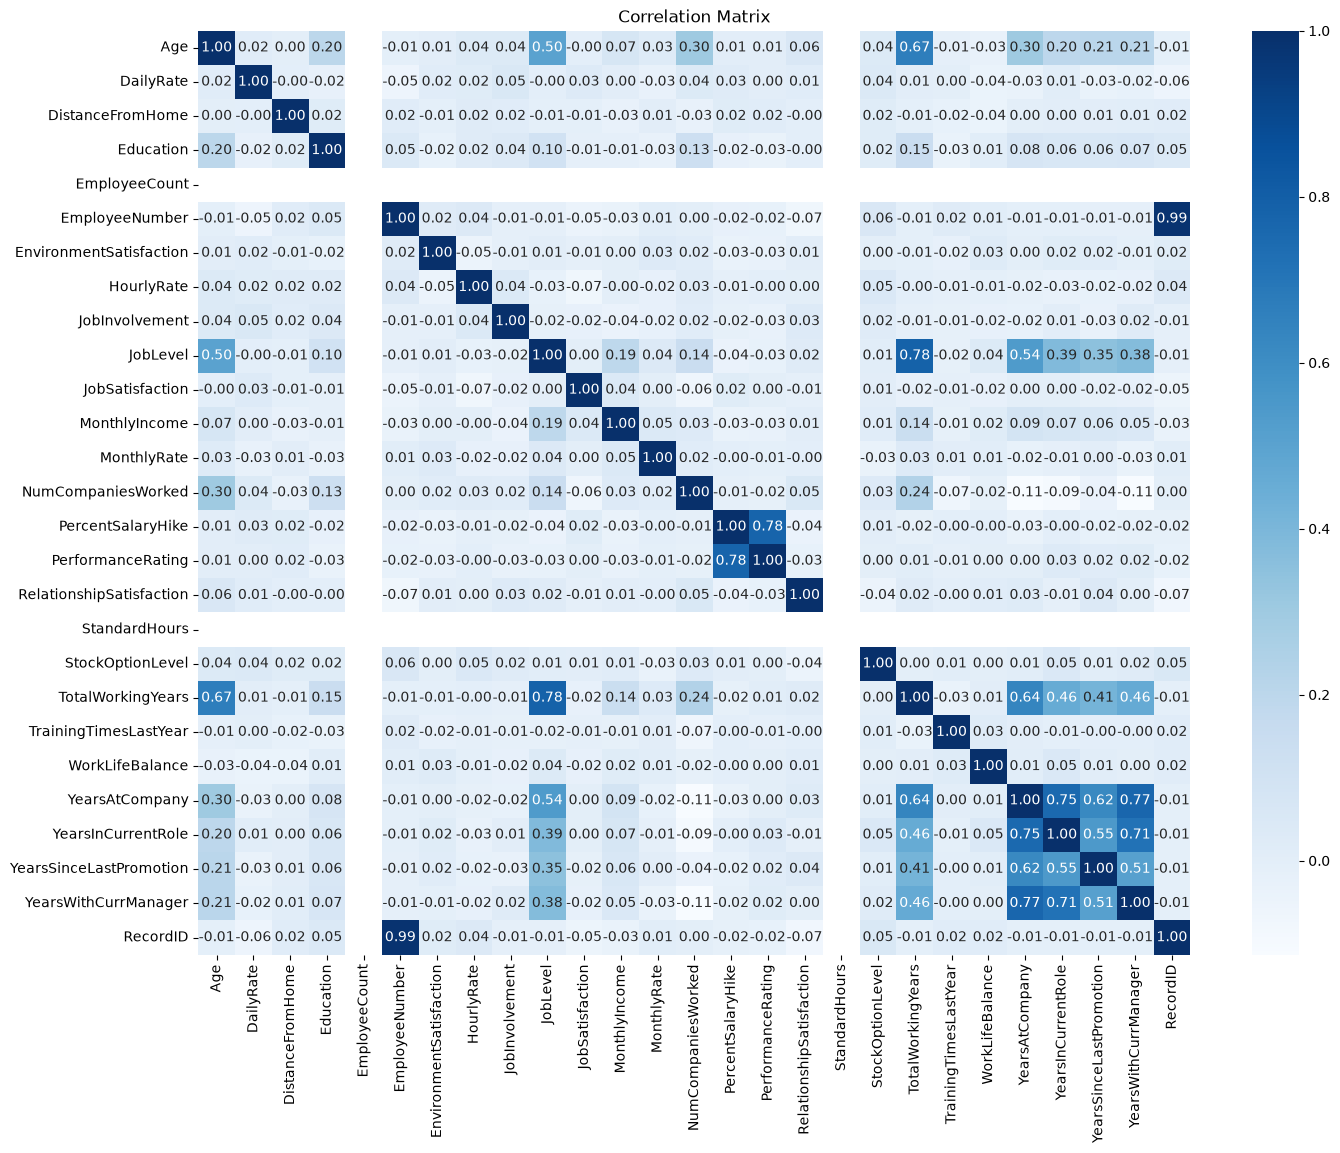

In [207]:
# Correlation matrix

plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Analyze Related Features

Instead of relying only on correlation values, we group related features based on their business meaning.

Highly correlated features are not necessarily redundant.

Some variables measure different aspects of the same concept and should be retained for business analysis.

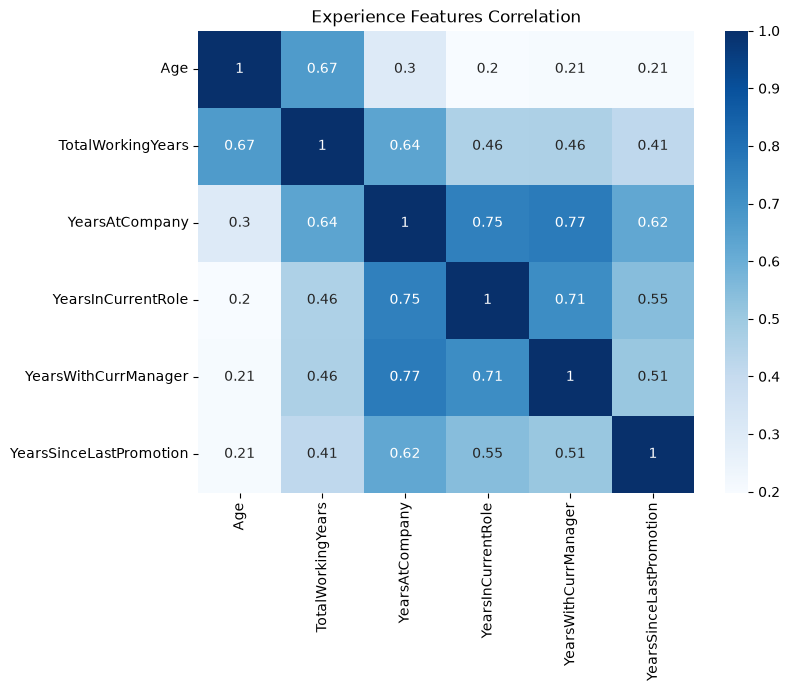

In [208]:
experience_features = [
    "Age",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
    "YearsSinceLastPromotion"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[experience_features].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Experience Features Correlation")

plt.show()

## 3.6 Inconsistent Values

### Why Are We Checking Inconsistent Values?

Categorical features should use consistent labels to represent the same category.

Inconsistent values, such as different spellings or letter cases, can split one category into multiple groups, leading to incorrect analysis and misleading visualizations.

In this step, we inspect all categorical features to ensure that each category is represented consistently.

In [209]:
# Display unique values for each categorical feature

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{'='*50}")
    print(f"{column}")
    print(f"{'='*50}")

    print(sorted(df[column].dropna().unique()))


Attrition
['No', 'Yes']

BusinessTravel
['Non-Travel', 'TRAVEL_RARELY', 'Travel Rarely', 'Travel-Rarely', 'Travel_Frequently', 'Travel_Rarely', 'travel_rarely']

Department
['Human Resourses', 'Research and Development', 'sales']

EducationField
['Human Resources', 'Life Sciences', 'Marketing', 'Medical', 'Other', 'Technical Degree']

Gender
[' Female ', ' Male ', 'Female', 'Male']

JobRole
['Healthcare Representative', 'Human Resources', 'Laboratory Technician', 'Manager', 'Manufacturing Director', 'Research Director', 'Research Scientist', 'Sales Ex.', 'Sales Executive', 'Sales Executve', 'Sales Representative', 'sales executive']

MaritalStatus
['Divorced', 'Married', 'Single']

Over18
['Y']

OverTime
['No', 'Yes']

ManagerNotes
['Average', 'Good', 'Needs Improvement']


C:\Users\soham\AppData\Local\Temp\ipykernel_21144\979719629.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [210]:
# Count unique values for each categorical feature

unique_summary = pd.DataFrame({
    "Feature": categorical_columns,
    "Unique Values": [df[col].nunique() for col in categorical_columns]
})

unique_summary

,Feature,Unique Values
0,Attrition,2
1,BusinessTravel,7
2,Department,3
3,EducationField,6
4,Gender,4
5,JobRole,12
6,MaritalStatus,3
7,Over18,1
8,OverTime,2
9,ManagerNotes,3


In [211]:
# Display value counts for each categorical feature

for column in categorical_columns:
    print(f"\n{'='*50}")
    print(f"{column}")
    print(f"{'='*50}")

    print(df[column].value_counts())


Attrition
Attrition
No     1256
Yes     239
Name: count, dtype: int64

BusinessTravel
BusinessTravel
Travel_Rarely        1051
Travel_Frequently     281
Non-Travel            151
Travel Rarely           3
Travel-Rarely           3
TRAVEL_RARELY           3
travel_rarely           3
Name: count, dtype: int64

Department
Department
Research and Development    973
sales                       456
Human Resourses              66
Name: count, dtype: int64

EducationField
EducationField
Life Sciences       605
Medical             460
Marketing           160
Technical Degree    128
Other                87
Human Resources      26
Name: count, dtype: int64

Gender
Gender
Male        878
Female      591
 Male        19
 Female       7
Name: count, dtype: int64

JobRole
JobRole
Sales Executive              321
Research Scientist           290
Laboratory Technician        259
Manufacturing Director       146
Healthcare Representative    131
Manager                      105
Sales Representative    

___
## 3.6 Invalid Values

### Why Are We Checking Invalid Values?

Invalid values are observations that violate logical business rules.

Unlike missing values or outliers, invalid values represent impossible or unrealistic records, such as an employee with more working years than their age or an employee older than the company's assumed retirement age.

In this step, we validate the dataset against predefined business rules to ensure that the data is logically consistent before moving to the cleaning phase.

___
### Business Rules

The following business rules will be used to validate the dataset:

- Employees should be between **18 and 60 years old**.
- Total working years should not exceed **Age − 18**.
- Years at the company should not exceed total working years.
- Years in the current role should not exceed years at the company.
- Years with the current manager should not exceed years at the company.
- Years since the last promotion should not exceed years at the company.

In [212]:
# Count invalid values based on business rules

invalid_summary = pd.DataFrame({
    "Business Rule": [
        "Age < 18",
        "Age > 60",
        "TotalWorkingYears > Age - 18",
        "YearsAtCompany > TotalWorkingYears",
        "YearsInCurrentRole > YearsAtCompany",
        "YearsWithCurrManager > YearsAtCompany",
        "YearsSinceLastPromotion > YearsAtCompany"
    ],
    "Invalid Records": [
        (df["Age"] < 18).sum(),
        (df["Age"] > 60).sum(),
        (df["TotalWorkingYears"] > (df["Age"] - 18)).sum(),
        (df["YearsAtCompany"] > df["TotalWorkingYears"]).sum(),
        (df["YearsInCurrentRole"] > df["YearsAtCompany"]).sum(),
        (df["YearsWithCurrManager"] > df["YearsAtCompany"]).sum(),
        (df["YearsSinceLastPromotion"] > df["YearsAtCompany"]).sum()
    ]
})

invalid_summary

,Business Rule,Invalid Records
0,Age < 18,2
1,Age > 60,1
2,TotalWorkingYears > Age - 18,2
3,YearsAtCompany > TotalWorkingYears,0
4,YearsInCurrentRole > YearsAtCompany,0
5,YearsWithCurrManager > YearsAtCompany,0
6,YearsSinceLastPromotion > YearsAtCompany,0


In [213]:
# Employees older than 60
df[df["Age"] > 60]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,RecordID,ManagerNotes
404,78.0,No,Travel_Rarely,1300,Research and Development,17,2,Medical,1,536,3,Male,79,3,2,Laboratory Technician,1,Divorced,4558.0,13535,1,Y,No,12,3,4,80,1,10.0,2,3,10.0,0,1,8,100405,Needs Improvement


In [214]:
# Employees younger than 18
df[df["Age"] < 18]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,RecordID,ManagerNotes
799,16.0,No,Travel_Rarely,469,Research and Development,2,2,Medical,1,1109,4,Male,35,3,4,Manager,1,Married,17665.0,14399,0,Y,No,17,3,4,80,1,23.0,3,3,22.0,6,13,7,100800,Average
872,17.0,No,Travel_Frequently,1146,sales,25,3,Medical,1,1220,2,Female,82,3,2,Sales Executive,3,Married,4539.0,4905,1,Y,No,12,3,1,80,1,10.0,3,2,10.0,7,0,1,100873,Good


In [215]:
# Working years exceed logical limit
df[df["TotalWorkingYears"] > (df["Age"] - 18)]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,RecordID,ManagerNotes
799,16.0,No,Travel_Rarely,469,Research and Development,2,2,Medical,1,1109,4,Male,35,3,4,Manager,1,Married,17665.0,14399,0,Y,No,17,3,4,80,1,23.0,3,3,22.0,6,13,7,100800,Average
872,17.0,No,Travel_Frequently,1146,sales,25,3,Medical,1,1220,2,Female,82,3,2,Sales Executive,3,Married,4539.0,4905,1,Y,No,12,3,1,80,1,10.0,3,2,10.0,7,0,1,100873,Good


___
## 3.7 Constant Features

### Why Are We Checking Constant Features?

Constant features contain only one unique value across all records.

Since these features do not vary between employees, they provide no useful information for analysis or predictive modeling.

In this step, we identify any constant features before deciding whether they should be removed during the data cleaning phase.

In [216]:
# Count unique values in each column
unique_counts = df.nunique()

# Select constant features
constant_features = unique_counts[unique_counts == 1]

constant_features

EmployeeCount    1
Over18           1
StandardHours    1
dtype: int64

In [217]:
# Number of constant features
print(f"Constant Features: {len(constant_features)}")

Constant Features: 3


___
## 3.8 Outlier Assessment

### Why Are We Checking Outliers?

Outliers are observations that differ significantly from the majority of the data.

However, not every outlier is an error. Some outliers represent valid business cases, such as highly experienced employees or executives with high salaries.

In this step, we identify potential outliers using the Interquartile Range (IQR) method and visualize their distribution. The final decision on whether to keep, cap, or remove these values will be made during the Data Cleaning phase.

In [218]:
# Select continuous numerical features suitable for IQR analysis
# Identifier and ordinal/rating columns are intentionally excluded.
continuous_columns = [
    "Age",
    "DailyRate",
    "DistanceFromHome",
    "HourlyRate",
    "MonthlyIncome",
    "MonthlyRate",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

continuous_columns = [
    column for column in continuous_columns
    if column in df.columns
]

continuous_columns

['Age',
 'DailyRate',
 'DistanceFromHome',
 'HourlyRate',
 'MonthlyIncome',
 'MonthlyRate',
 'TotalWorkingYears',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

C:\Users\soham\AppData\Local\Temp\ipykernel_21144\2356365948.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[column].dropna(), vert=True)
C:\Users\soham\AppData\Local\Temp\ipykernel_21144\2356365948.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[column].dropna(), vert=True)
C:\Users\soham\AppData\Local\Temp\ipykernel_21144\2356365948.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[column].dropna(), vert=True)
C:\Users\soham\AppData\Local\Temp\ipykernel_21144\2356365948.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use

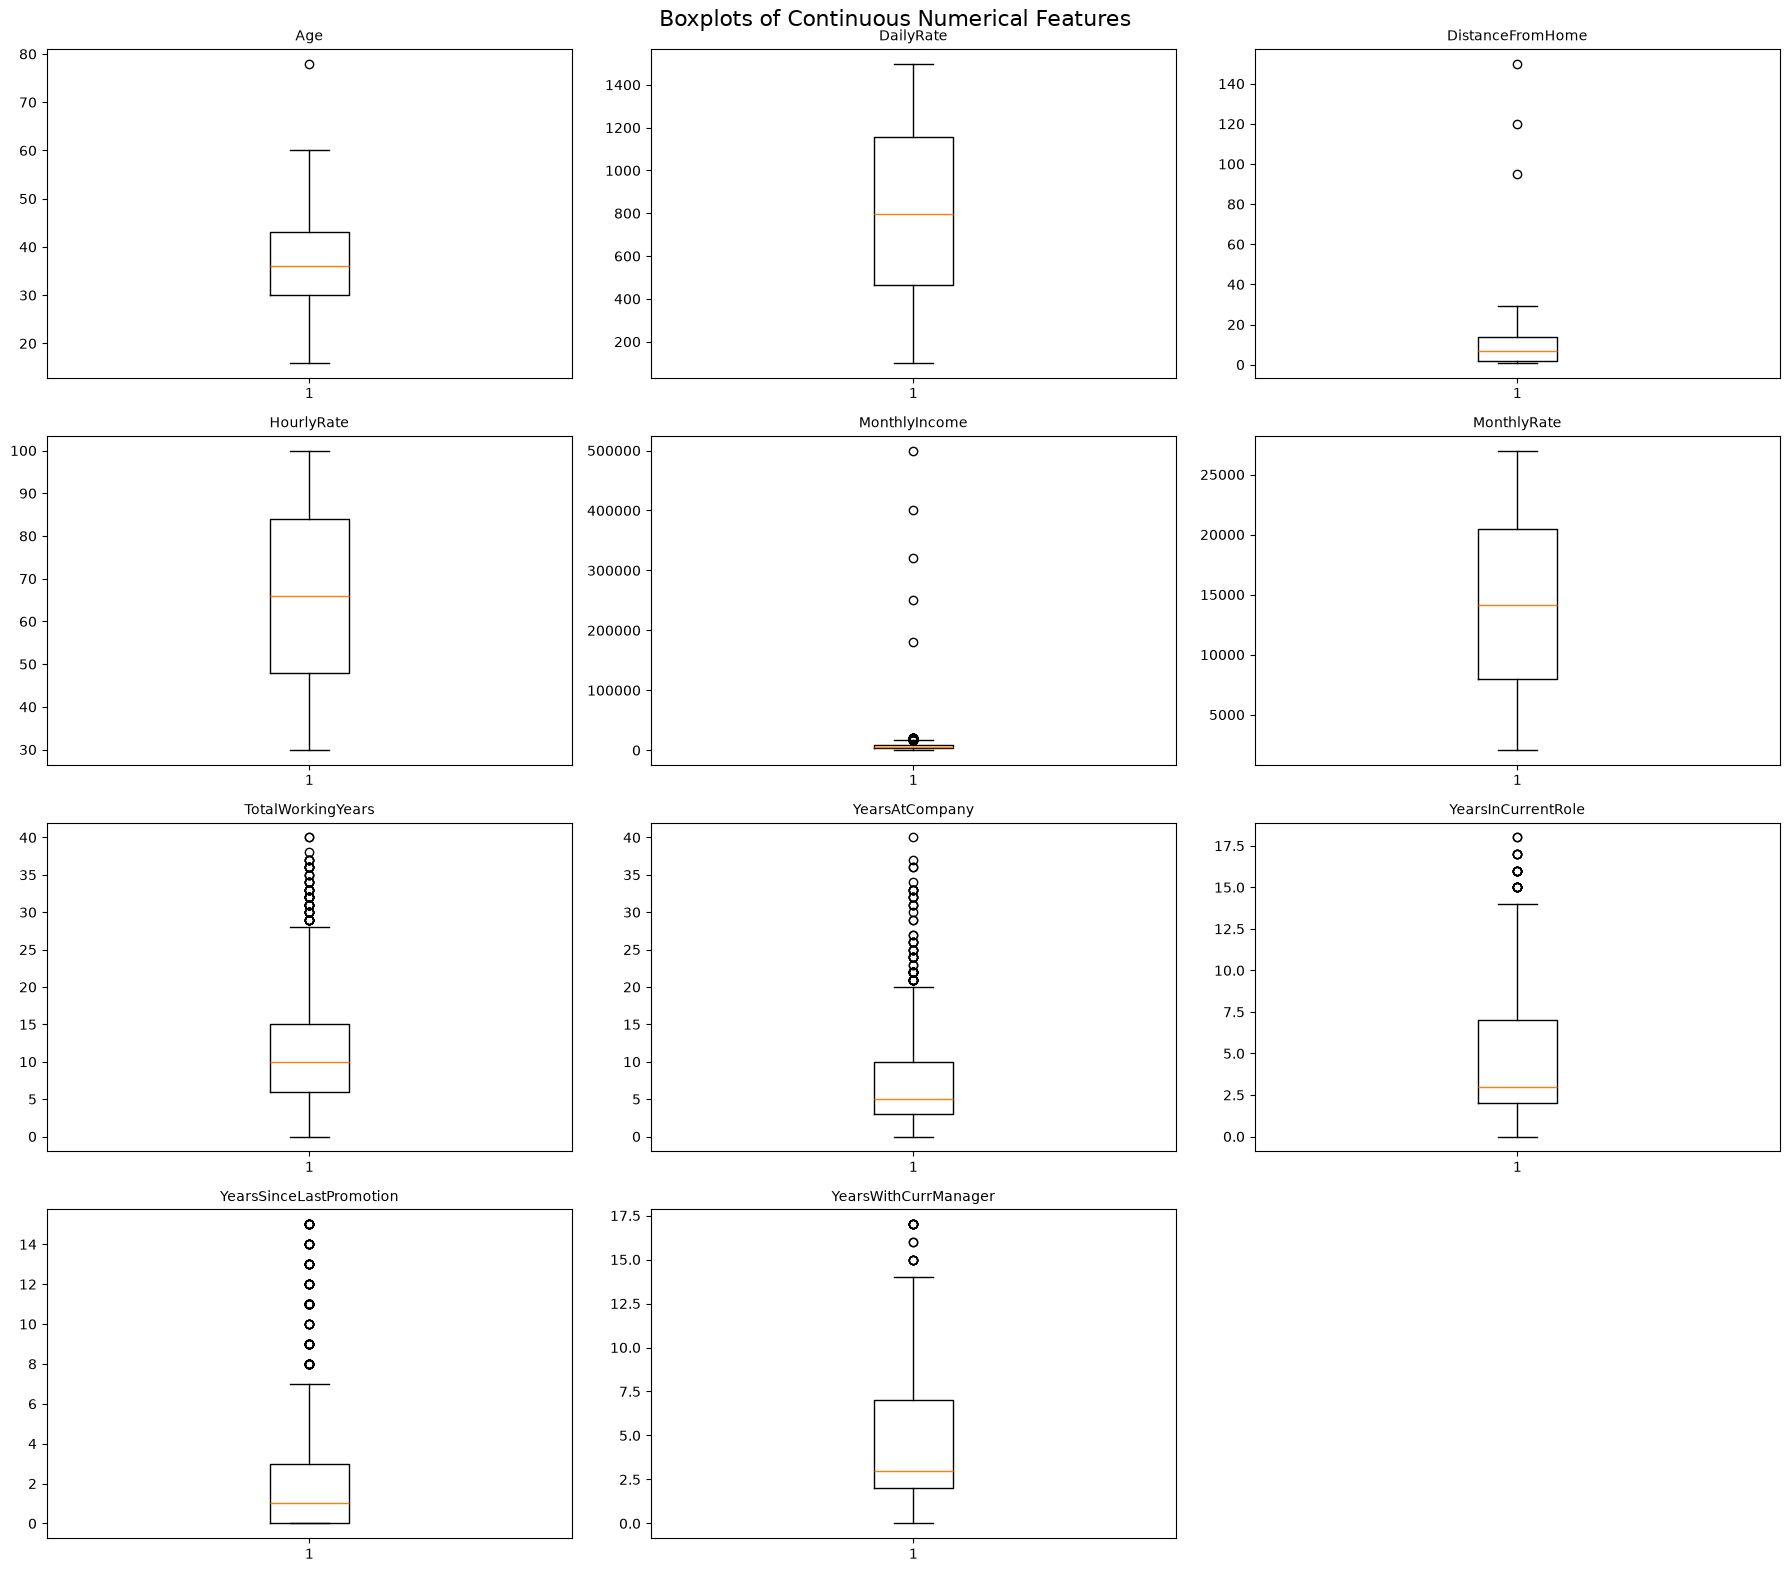

In [219]:
# Plot boxplots for continuous numerical features
import math

n_columns = 3
n_rows = math.ceil(len(continuous_columns) / n_columns)

fig, axes = plt.subplots(n_rows, n_columns, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, column in enumerate(continuous_columns):
    axes[i].boxplot(df[column].dropna(), vert=True)
    axes[i].set_title(column, fontsize=10)

for j in range(len(continuous_columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots of Continuous Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

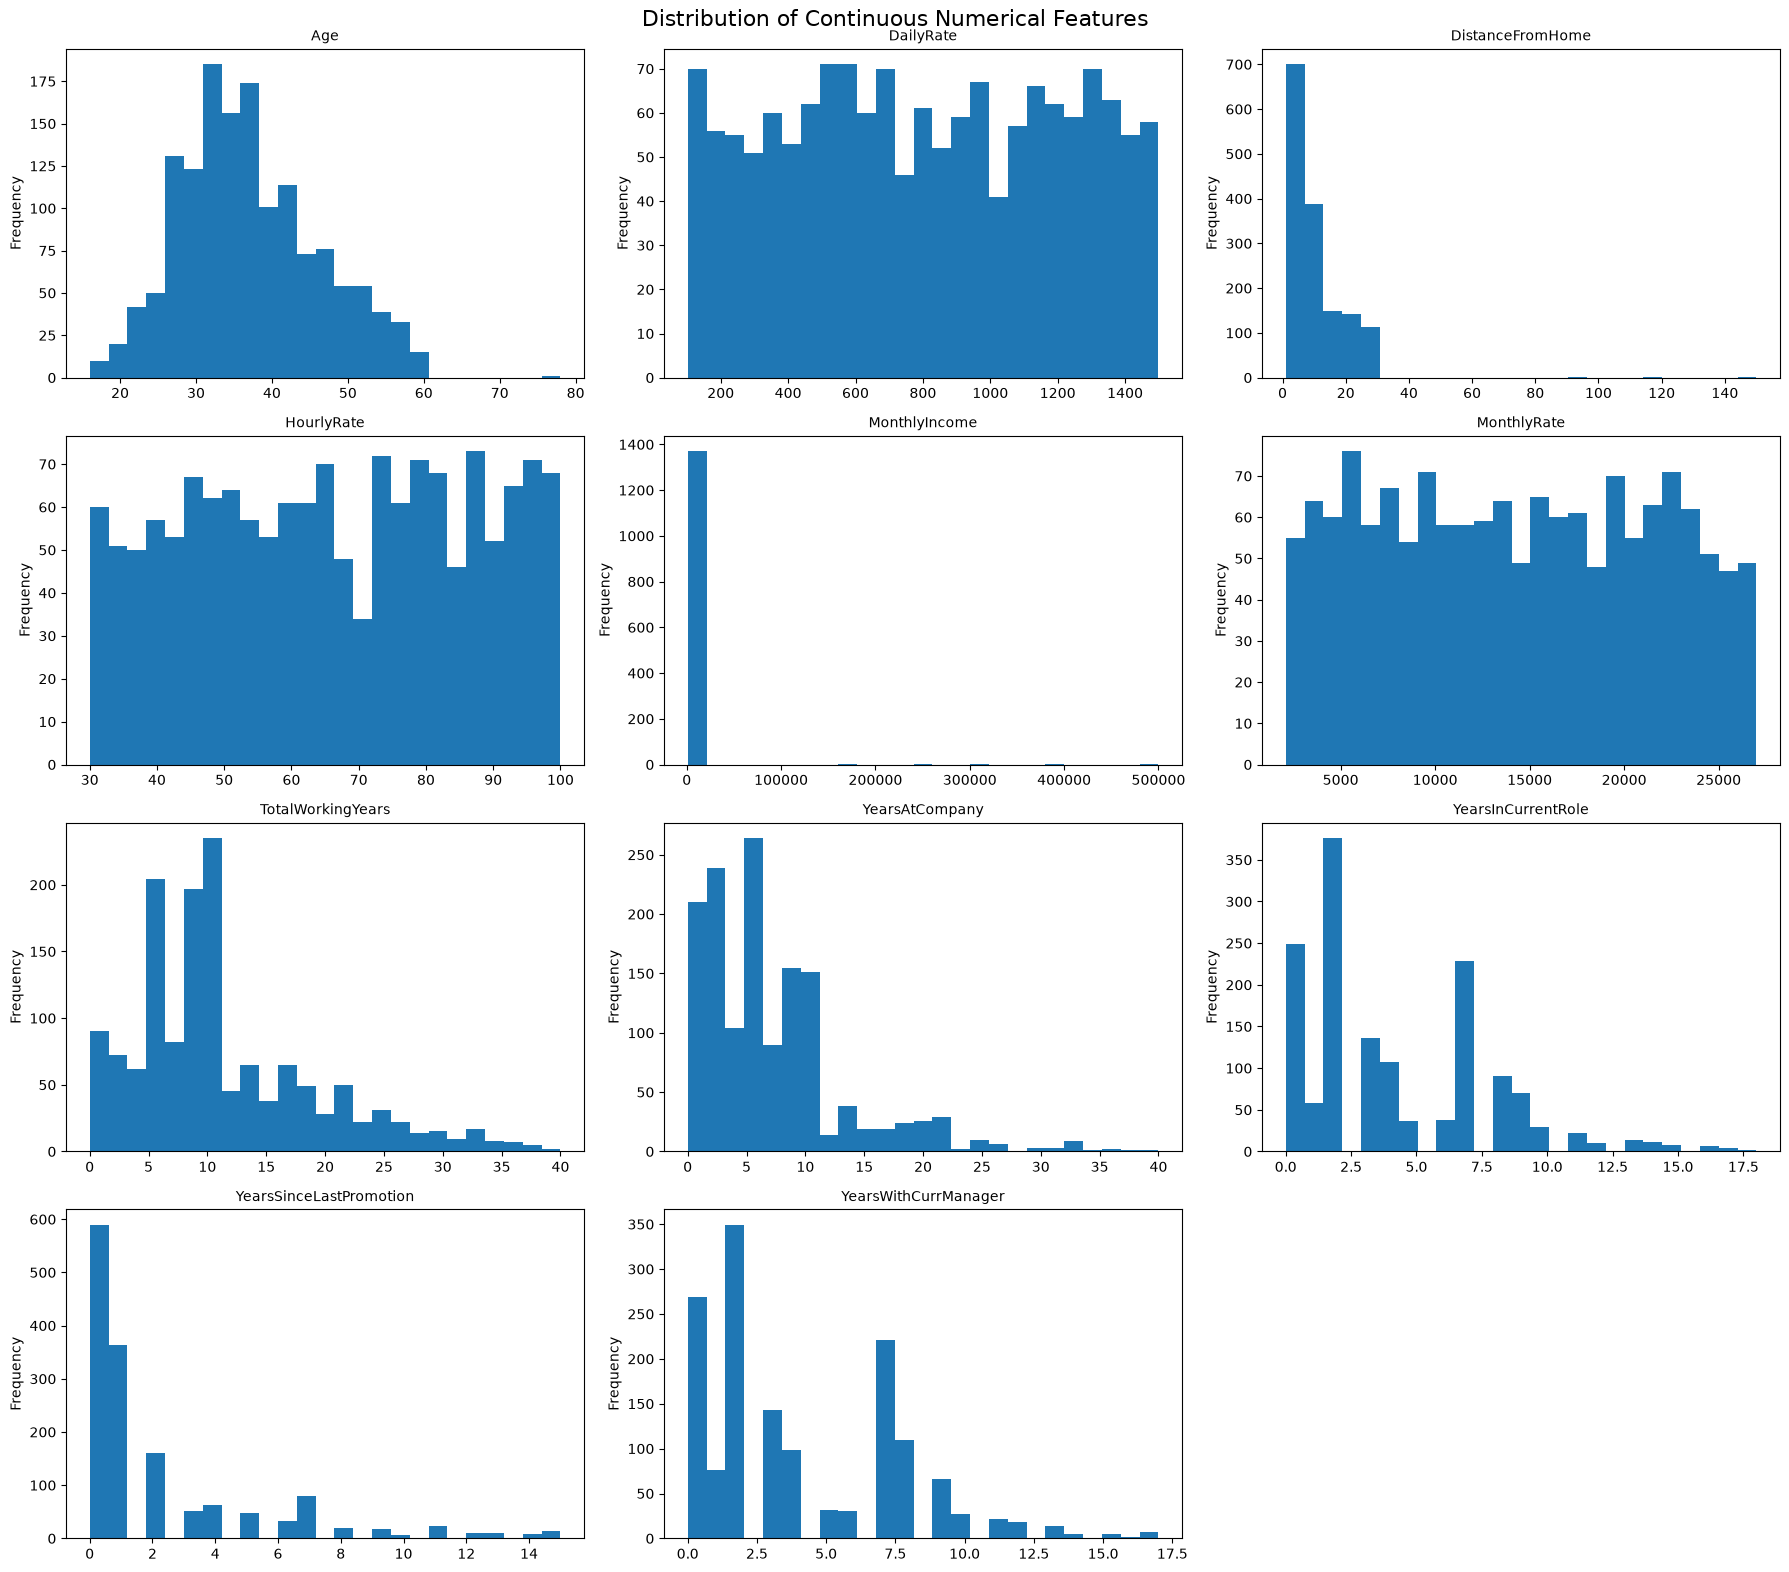

In [220]:
# Plot distributions for continuous numerical features
import math

n_columns = 3
n_rows = math.ceil(len(continuous_columns) / n_columns)

fig, axes = plt.subplots(n_rows, n_columns, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, column in enumerate(continuous_columns):
    axes[i].hist(df[column].dropna(), bins=25)
    axes[i].set_title(column, fontsize=10)
    axes[i].set_ylabel("Frequency")

for j in range(len(continuous_columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of Continuous Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

In [221]:
# Count potential outliers using the IQR method
outlier_summary = []

for column in continuous_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound)
        | (df[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": column,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": outlier_count
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary.sort_values("Outliers", ascending=False)

,Feature,Lower Bound,Upper Bound,Outliers
9,YearsSinceLastPromotion,-4.50,7.50,109
4,MonthlyIncome,-5364.00,16768.00,105
7,YearsAtCompany,-7.50,20.50,67
6,TotalWorkingYears,-7.50,28.50,63
8,YearsInCurrentRole,-5.50,14.50,21
10,YearsWithCurrManager,-5.50,14.50,14
2,DistanceFromHome,-16.00,32.00,3
0,Age,10.50,62.50,1
1,DailyRate,-573.00,2195.00,0
5,MonthlyRate,-10621.25,39068.75,0


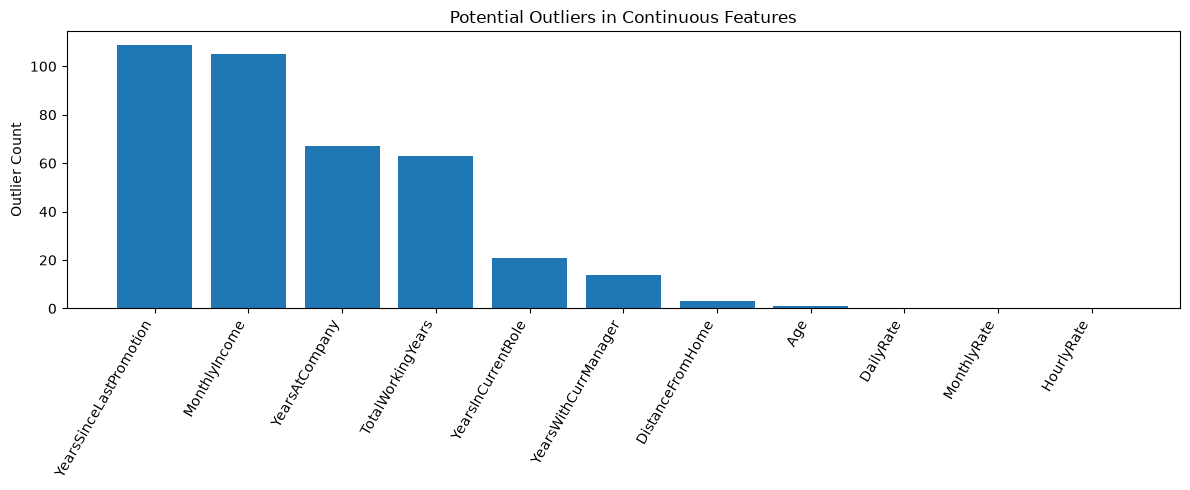

In [222]:
# Plot the number of potential outliers
outlier_plot = outlier_summary.sort_values("Outliers", ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(outlier_plot["Feature"], outlier_plot["Outliers"])
plt.xticks(rotation=60, ha="right")
plt.title("Potential Outliers in Continuous Features")
plt.ylabel("Outlier Count")
plt.tight_layout()
plt.show()

# Phase 3 Summary

The dataset has been thoroughly assessed for data quality.

The assessment included:

- Missing values
- Duplicate records
- Duplicate employee IDs
- Data type validation
- Inconsistent values
- Invalid values
- Constant features
- Outlier assessment

At this stage, no modifications have been made to the dataset.

In the next phase, we will apply the appropriate cleaning techniques based on the findings from this assessment.

___
# Phase 4: Data Cleaning

## Why Do We Clean the Data?

After assessing the dataset, we identified several data quality issues that could affect the reliability of our analysis.

The purpose of this phase is to improve the quality of the dataset while preserving as much useful business information as possible.

We will clean the data gradually, verifying each modification before moving to the next step.

___
## 4.1 Create a Working Copy

Before applying any modifications, we create a copy of the original dataset.

This allows us to preserve the raw dataset and compare it with the cleaned version whenever necessary.

In [223]:
# Create a copy of the dataset

df_clean = df.copy()

# Display dataset shape
print(df_clean.shape)

(1495, 37)


___
## 4.2 Remove Duplicate Records

Duplicate records can bias the analysis by counting the same employee multiple times.

In this step, we identify duplicate rows and remove them while keeping the first occurrence.

In [224]:
# Number of duplicate rows

print("Duplicate Records:", df_clean.duplicated().sum())

Duplicate Records: 25


In [225]:
# Display duplicate rows

df_clean[df_clean.duplicated()].head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,RecordID,ManagerNotes
1470,32.0,No,Travel_Frequently,116,Research and Development,13,3,Other,1,1234,3,Female,77,2,1,Laboratory Technician,2,Married,2743.0,7331,1,Y,No,20,4,3,80,1,2.0,2,3,2.0,2,2,2,100881,NaN
1471,53.0,No,Travel_Rarely,1436,sales,6,2,Marketing,1,205,2,Male,34,3,2,Sales Representative,3,Married,NaN,16047,2,Y,Yes,20,4,4,80,1,13.0,3,1,7.0,7,4,5,100153,Needs Improvement
1472,39.0,No,Travel_Rarely,613,Research and Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991.0,21457,4,Y,No,15,3,1,80,1,9.0,5,3,7.0,7,1,7,101467,NaN
1473,34.0,No,Travel_Rarely,971,sales,1,3,Technical Degree,1,1535,4,Male,64,2,3,Sales Executive,3,Married,7083.0,12288,1,Y,Yes,14,3,4,80,0,10.0,3,3,10.0,9,8,6,101085,NaN
1474,50.0,No,Travel_Frequently,333,Research and Development,22,5,Medical,1,1539,3,Male,88,1,4,Research Director,4,Single,14411.0,24450,1,Y,Yes,13,3,4,80,0,32.0,2,3,32.0,6,13,9,101087,NaN


In [226]:
# Remove duplicate rows

df_clean = df_clean.drop_duplicates()

In [227]:
# Verify duplicates

print("Duplicate Records:", df_clean.duplicated().sum())

Duplicate Records: 0


___
## 4.3 Verify Employee IDs

Each employee should have a unique Employee Number.

We verify that there are no duplicated employee identifiers before continuing.

In [228]:
# Check duplicate employee IDs

duplicate_ids = df_clean["EmployeeNumber"].duplicated().sum()

print("Duplicate Employee IDs:", duplicate_ids)

Duplicate Employee IDs: 0


___
## 4.4 Verify Data Types

Each feature should use an appropriate data type that matches its business meaning.

We review the data types before applying any transformations.

In [229]:
# Display data types

df_clean.dtypes

Age                         float64
Attrition                       str
BusinessTravel                  str
DailyRate                     int64
Department                      str
DistanceFromHome              int64
Education                     int64
EducationField                  str
EmployeeCount                 int64
EmployeeNumber                int64
EnvironmentSatisfaction       int64
Gender                          str
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                         str
JobSatisfaction               int64
MaritalStatus                   str
MonthlyIncome               float64
MonthlyRate                   int64
NumCompaniesWorked            int64
Over18                          str
OverTime                        str
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StandardHours                 int64
StockOptionLevel            

___
## 4.5 Handle Inconsistent Values

Categorical features should use one consistent representation for each category.

We inspect categorical variables and standardize values when necessary.

In [230]:
# Display unique values before standardization
categorical_columns = df_clean.select_dtypes(
    include=["object", "string"]
).columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df_clean[column].unique())


Attrition
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

BusinessTravel
<StringArray>
[    'Travel_Rarely', 'Travel_Frequently',     'Travel Rarely',
     'Travel-Rarely',        'Non-Travel',     'TRAVEL_RARELY',
     'travel_rarely']
Length: 7, dtype: str

Department
<StringArray>
['sales', 'Research and Development', 'Human Resourses']
Length: 3, dtype: str

EducationField
<StringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',                nan,
  'Human Resources']
Length: 7, dtype: str

Gender
<StringArray>
['Female', 'Male', ' Male ', ' Female ']
Length: 4, dtype: str

JobRole
<StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
                         nan,                 'Sales Ex.',
           'Human Resources',     

In [231]:
# Remove leading/trailing spaces from every text feature
text_columns = df_clean.select_dtypes(
    include=["object", "string"]
).columns

for column in text_columns:
    df_clean[column] = df_clean[column].str.strip()

# Standardize BusinessTravel values
business_travel_key = (
    df_clean["BusinessTravel"]
    .str.lower()
    .str.replace("-", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

df_clean["BusinessTravel"] = business_travel_key.replace({
    "travel_rarely": "Travel_Rarely",
    "travel_frequently": "Travel_Frequently",
    "non_travel": "Non-Travel"
})

In [232]:
# Standardize Department and JobRole values
df_clean["Department"] = df_clean["Department"].replace({
    "sales": "Sales",
    "Human Resourses": "Human Resources"
})

df_clean["JobRole"] = df_clean["JobRole"].replace({
    "Sales Ex.": "Sales Executive",
    "Sales Executve": "Sales Executive",
    "sales executive": "Sales Executive"
})

In [233]:
# Verify corrected categorical values
for column in ["BusinessTravel", "Department", "Gender", "JobRole"]:
    print(f"\n{column}")
    print(sorted(df_clean[column].dropna().unique()))


BusinessTravel
['Non-Travel', 'Travel_Frequently', 'Travel_Rarely']

Department
['Human Resources', 'Research and Development', 'Sales']

Gender
['Female', 'Male']

JobRole
['Healthcare Representative', 'Human Resources', 'Laboratory Technician', 'Manager', 'Manufacturing Director', 'Research Director', 'Research Scientist', 'Sales Executive', 'Sales Representative']


___
## 4.6 Handle Invalid Values

Some records may satisfy the correct data type but violate business rules.

In this step, we validate the dataset against logical business constraints before handling missing values.

In [234]:
# Identify values that violate explicit business rules
invalid_age = (
    df_clean["Age"].notna()
    & ~df_clean["Age"].between(18, 60)
)

invalid_distance = (
    df_clean["DistanceFromHome"].notna()
    & ~df_clean["DistanceFromHome"].between(1, 29)
)

print("Invalid Age:", invalid_age.sum())
print("Invalid DistanceFromHome:", invalid_distance.sum())

Invalid Age: 3
Invalid DistanceFromHome: 3


In [235]:
# Convert invalid values to missing values instead of deleting whole records
df_clean.loc[invalid_age, "Age"] = np.nan
df_clean.loc[invalid_distance, "DistanceFromHome"] = np.nan

In [236]:
# Total working years cannot exceed the possible working period
invalid_experience = (
    df_clean["Age"].notna()
    & df_clean["TotalWorkingYears"].notna()
    & (
        df_clean["TotalWorkingYears"]
        > df_clean["Age"] - 18
    )
)

print("Invalid TotalWorkingYears:", invalid_experience.sum())

# The questionable field is converted to NaN and imputed later.
df_clean.loc[invalid_experience, "TotalWorkingYears"] = np.nan

Invalid TotalWorkingYears: 0


In [237]:
# Years at the company cannot exceed total working years
invalid_company = (
    df_clean["YearsAtCompany"].notna()
    & df_clean["TotalWorkingYears"].notna()
    & (
        df_clean["YearsAtCompany"]
        > df_clean["TotalWorkingYears"]
    )
)

print("Invalid YearsAtCompany:", invalid_company.sum())
df_clean.loc[invalid_company, "YearsAtCompany"] = np.nan

Invalid YearsAtCompany: 0


In [238]:
# Years in the current role cannot exceed years at the company
invalid_role = (
    df_clean["YearsInCurrentRole"].notna()
    & df_clean["YearsAtCompany"].notna()
    & (
        df_clean["YearsInCurrentRole"]
        > df_clean["YearsAtCompany"]
    )
)

print("Invalid YearsInCurrentRole:", invalid_role.sum())
df_clean.loc[invalid_role, "YearsInCurrentRole"] = np.nan

Invalid YearsInCurrentRole: 0


In [239]:
# Years with the current manager cannot exceed years at the company
invalid_manager = (
    df_clean["YearsWithCurrManager"].notna()
    & df_clean["YearsAtCompany"].notna()
    & (
        df_clean["YearsWithCurrManager"]
        > df_clean["YearsAtCompany"]
    )
)

print("Invalid YearsWithCurrManager:", invalid_manager.sum())
df_clean.loc[invalid_manager, "YearsWithCurrManager"] = np.nan

Invalid YearsWithCurrManager: 0


In [240]:
# Years since the last promotion cannot exceed years at the company
invalid_promotion = (
    df_clean["YearsSinceLastPromotion"].notna()
    & df_clean["YearsAtCompany"].notna()
    & (
        df_clean["YearsSinceLastPromotion"]
        > df_clean["YearsAtCompany"]
    )
)

print("Invalid YearsSinceLastPromotion:", invalid_promotion.sum())
df_clean.loc[invalid_promotion, "YearsSinceLastPromotion"] = np.nan

Invalid YearsSinceLastPromotion: 0


In [241]:
# Verify that no remaining non-missing values violate the rules
print("Age outside 18-60:",
      (df_clean["Age"].notna() & ~df_clean["Age"].between(18, 60)).sum())

print("Working Years > Age - 18:",
      (df_clean["TotalWorkingYears"].notna()
       & df_clean["Age"].notna()
       & (df_clean["TotalWorkingYears"] > df_clean["Age"] - 18)).sum())

print("YearsAtCompany > TotalWorkingYears:",
      (df_clean["YearsAtCompany"].notna()
       & df_clean["TotalWorkingYears"].notna()
       & (df_clean["YearsAtCompany"] > df_clean["TotalWorkingYears"])).sum())

Age outside 18-60: 0
Working Years > Age - 18: 0
YearsAtCompany > TotalWorkingYears: 0


___
## 4.7 Handle Missing Values

### Why Are We Handling Missing Values?

Missing values can affect statistical analysis, visualizations, and machine learning models.

Instead of applying one solution to every feature, we first examine the amount and distribution of missing values.

Then, we choose the most appropriate treatment for each feature based on its business meaning and the percentage of missing data.

In [242]:
# Count missing values

missing_values = df_clean.isnull().sum()

# Calculate missing percentage

missing_percentage = (
    missing_values / len(df_clean) * 100
).round(2)

# Create summary table

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage
})

# Keep only columns with missing values

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
]

missing_summary.sort_values(
    by="Missing Percentage (%)",
    ascending=False
)

,Missing Values,Missing Percentage (%)
ManagerNotes,882,60.00
MonthlyIncome,118,8.03
YearsAtCompany,74,5.03
TotalWorkingYears,59,4.01
Age,47,3.20
EducationField,29,1.97
JobRole,15,1.02
DistanceFromHome,3,0.20


### Missing Values Analysis

Before filling or removing missing values, we evaluate each feature individually.

The decision depends on:

- The percentage of missing values.
- The business importance of the feature.
- The data type.
- Whether the feature is useful for later analysis.

In [243]:
# Create a dynamic missing-values decision table
decision_table = missing_summary.copy()

decisions = {
    "ManagerNotes": (
        "Drop",
        "More than 50% missing and not required for the analysis"
    ),
    "Age": (
        "Group median",
        "Numerical feature; impute using employees at the same JobLevel"
    ),
    "MonthlyIncome": (
        "Group median",
        "Income depends strongly on JobLevel and JobRole"
    ),
    "DistanceFromHome": (
        "Median",
        "Invalid entries were converted to missing values"
    ),
    "TotalWorkingYears": (
        "Group median",
        "Experience differs by JobLevel"
    ),
    "YearsAtCompany": (
        "Group median",
        "Tenure differs by JobLevel"
    ),
    "YearsInCurrentRole": (
        "Group median",
        "Logical invalid values were converted to missing"
    ),
    "YearsWithCurrManager": (
        "Group median",
        "Logical invalid values were converted to missing"
    ),
    "YearsSinceLastPromotion": (
        "Group median",
        "Logical invalid values were converted to missing"
    ),
    "EducationField": (
        "Unknown",
        "Avoid assigning an unsupported category"
    ),
    "JobRole": (
        "Unknown",
        "Avoid assigning an unsupported job role"
    )
}

decision_table["Decision"] = [
    decisions.get(index, ("Review", "Needs manual review"))[0]
    for index in decision_table.index
]

decision_table["Reason"] = [
    decisions.get(index, ("Review", "Needs manual review"))[1]
    for index in decision_table.index
]

decision_table

,Missing Values,Missing Percentage (%),Decision,Reason
Age,47,3.20,Group median,Numerical feature; impute using employees at the same JobLevel
DistanceFromHome,3,0.20,Median,Invalid entries were converted to missing values
EducationField,29,1.97,Unknown,Avoid assigning an unsupported category
JobRole,15,1.02,Unknown,Avoid assigning an unsupported job role
MonthlyIncome,118,8.03,Group median,Income depends strongly on JobLevel and JobRole
TotalWorkingYears,59,4.01,Group median,Experience differs by JobLevel
YearsAtCompany,74,5.03,Group median,Tenure differs by JobLevel
ManagerNotes,882,60.00,Drop,More than 50% missing and not required for the analysis


### Drop High Missing Feature

The **ManagerNotes** column contains more than 60% missing values and is not required for the business analysis.

Therefore, it will be removed from the dataset.

In [244]:
# Drop ManagerNotes

df_clean.drop(columns="ManagerNotes", inplace=True)

In [245]:
df_clean.isnull().sum()

Age                          47
Attrition                     0
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              3
Education                     0
EducationField               29
EmployeeCount                 0
EmployeeNumber                0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                      15
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome               118
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears            59
TrainingTimesLastYear         0
WorkLifeBalance               0
YearsAtC

### Fill Missing Values in Age and TotalWorkingYears

Age and total experience are important numerical features. Missing values are imputed using the median of employees at the same **JobLevel**, followed by the overall median as a fallback. This is more reliable than assuming every employee started working at exactly age 18.

In [246]:
# Fill Age using the median within each JobLevel
age_group_median = (
    df_clean.groupby("JobLevel")["Age"]
    .transform("median")
)

df_clean["Age"] = (
    df_clean["Age"]
    .fillna(age_group_median)
    .fillna(df_clean["Age"].median())
)

# Fill TotalWorkingYears using the median within each JobLevel
experience_group_median = (
    df_clean.groupby("JobLevel")["TotalWorkingYears"]
    .transform("median")
)

df_clean["TotalWorkingYears"] = (
    df_clean["TotalWorkingYears"]
    .fillna(experience_group_median)
    .fillna(df_clean["TotalWorkingYears"].median())
)

# Enforce the age-based upper limit after imputation
maximum_possible_experience = (df_clean["Age"] - 18).clip(lower=0)
df_clean["TotalWorkingYears"] = np.minimum(
    df_clean["TotalWorkingYears"],
    maximum_possible_experience
)

### Fill Missing Values in YearsAtCompany and Related Tenure Features

Tenure features are imputed using medians within the same **JobLevel**. After imputation, each feature is capped using its logical parent feature to preserve consistency.

In [247]:
# Fill YearsAtCompany using JobLevel median
tenure_group_median = (
    df_clean.groupby("JobLevel")["YearsAtCompany"]
    .transform("median")
)

df_clean["YearsAtCompany"] = (
    df_clean["YearsAtCompany"]
    .fillna(tenure_group_median)
    .fillna(df_clean["YearsAtCompany"].median())
)

# YearsAtCompany cannot exceed TotalWorkingYears
df_clean["YearsAtCompany"] = np.minimum(
    df_clean["YearsAtCompany"],
    df_clean["TotalWorkingYears"]
)

# Fill and cap related tenure features
related_tenure_columns = [
    "YearsInCurrentRole",
    "YearsWithCurrManager",
    "YearsSinceLastPromotion"
]

for column in related_tenure_columns:
    group_median = (
        df_clean.groupby("JobLevel")[column]
        .transform("median")
    )

    df_clean[column] = (
        df_clean[column]
        .fillna(group_median)
        .fillna(df_clean[column].median())
    )

    df_clean[column] = np.minimum(
        df_clean[column],
        df_clean["YearsAtCompany"]
    )

### Fill Missing Values in MonthlyIncome and DistanceFromHome

Monthly income is imputed using employees with the same **JobLevel** and **JobRole**, followed by the JobLevel median and overall median. Distance from home is filled using its median after invalid entries are converted to missing values.

In [248]:
# Cap MonthlyIncome instead of removing outliers
df_clean["MonthlyIncome"] = df_clean["MonthlyIncome"].clip(
    lower=1000,
    upper=50000
)

In [249]:
# Fill MonthlyIncome using JobLevel and JobRole medians
income_role_level_median = (
    df_clean.groupby(["JobLevel", "JobRole"])["MonthlyIncome"]
    .transform("median")
)

income_level_median = (
    df_clean.groupby("JobLevel")["MonthlyIncome"]
    .transform("median")
)

df_clean["MonthlyIncome"] = (
    df_clean["MonthlyIncome"]
    .fillna(income_role_level_median)
    .fillna(income_level_median)
    .fillna(df_clean["MonthlyIncome"].median())
)

# Fill DistanceFromHome with the median
df_clean["DistanceFromHome"] = (
    df_clean["DistanceFromHome"]
    .fillna(df_clean["DistanceFromHome"].median())
)

In [250]:
# Label missing EducationField values explicitly
df_clean["EducationField"] = (
    df_clean["EducationField"]
    .fillna("Unknown")
)

In [251]:
# Label missing JobRole values explicitly
df_clean["JobRole"] = (
    df_clean["JobRole"]
    .fillna("Unknown")
)

In [252]:
# Convert whole-number numerical features to integer types
integer_columns = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

integer_columns = [
    column for column in integer_columns
    if column in df_clean.columns
]

df_clean[integer_columns] = (
    df_clean[integer_columns]
    .round()
    .astype(int)
)

### Verify Missing Values

After applying the selected cleaning strategies, we verify that no missing values remain in the dataset.

In [253]:
# Verify the entire cleaned dataset
remaining_missing = df_clean.isnull().sum()

print("Columns with missing values:")
print(remaining_missing[remaining_missing > 0])
print("\nTotal Missing Values:", remaining_missing.sum())
print("Duplicate Rows:", df_clean.duplicated().sum())

# Verify logical relationships
print("Age outside 18-60:", (~df_clean["Age"].between(18, 60)).sum())
print("Working Years > Age - 18:",
      (df_clean["TotalWorkingYears"] > df_clean["Age"] - 18).sum())
print("YearsAtCompany > TotalWorkingYears:",
      (df_clean["YearsAtCompany"] > df_clean["TotalWorkingYears"]).sum())
print("YearsInCurrentRole > YearsAtCompany:",
      (df_clean["YearsInCurrentRole"] > df_clean["YearsAtCompany"]).sum())
print("YearsWithCurrManager > YearsAtCompany:",
      (df_clean["YearsWithCurrManager"] > df_clean["YearsAtCompany"]).sum())
print("YearsSinceLastPromotion > YearsAtCompany:",
      (df_clean["YearsSinceLastPromotion"] > df_clean["YearsAtCompany"]).sum())

assert remaining_missing.sum() == 0
assert df_clean.duplicated().sum() == 0

Columns with missing values:
Series([], dtype: int64)

Total Missing Values: 0
Duplicate Rows: 0
Age outside 18-60: 0
Working Years > Age - 18: 0
YearsAtCompany > TotalWorkingYears: 0
YearsInCurrentRole > YearsAtCompany: 0
YearsWithCurrManager > YearsAtCompany: 0
YearsSinceLastPromotion > YearsAtCompany: 0


___
## 4.8 Handle Outliers

### Why Are We Checking Outliers?

Outliers are observations that differ significantly from the rest of the data.

Some outliers are caused by data entry errors, while others represent real business cases.

Before removing any values, we first identify the outliers and evaluate whether they should be retained or treated.

In [254]:
# Select continuous numerical columns only
continuous_columns_clean = [
    "Age",
    "DailyRate",
    "DistanceFromHome",
    "HourlyRate",
    "MonthlyIncome",
    "MonthlyRate",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

continuous_columns_clean = [
    column for column in continuous_columns_clean
    if column in df_clean.columns
]

continuous_columns_clean

['Age',
 'DailyRate',
 'DistanceFromHome',
 'HourlyRate',
 'MonthlyIncome',
 'MonthlyRate',
 'TotalWorkingYears',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

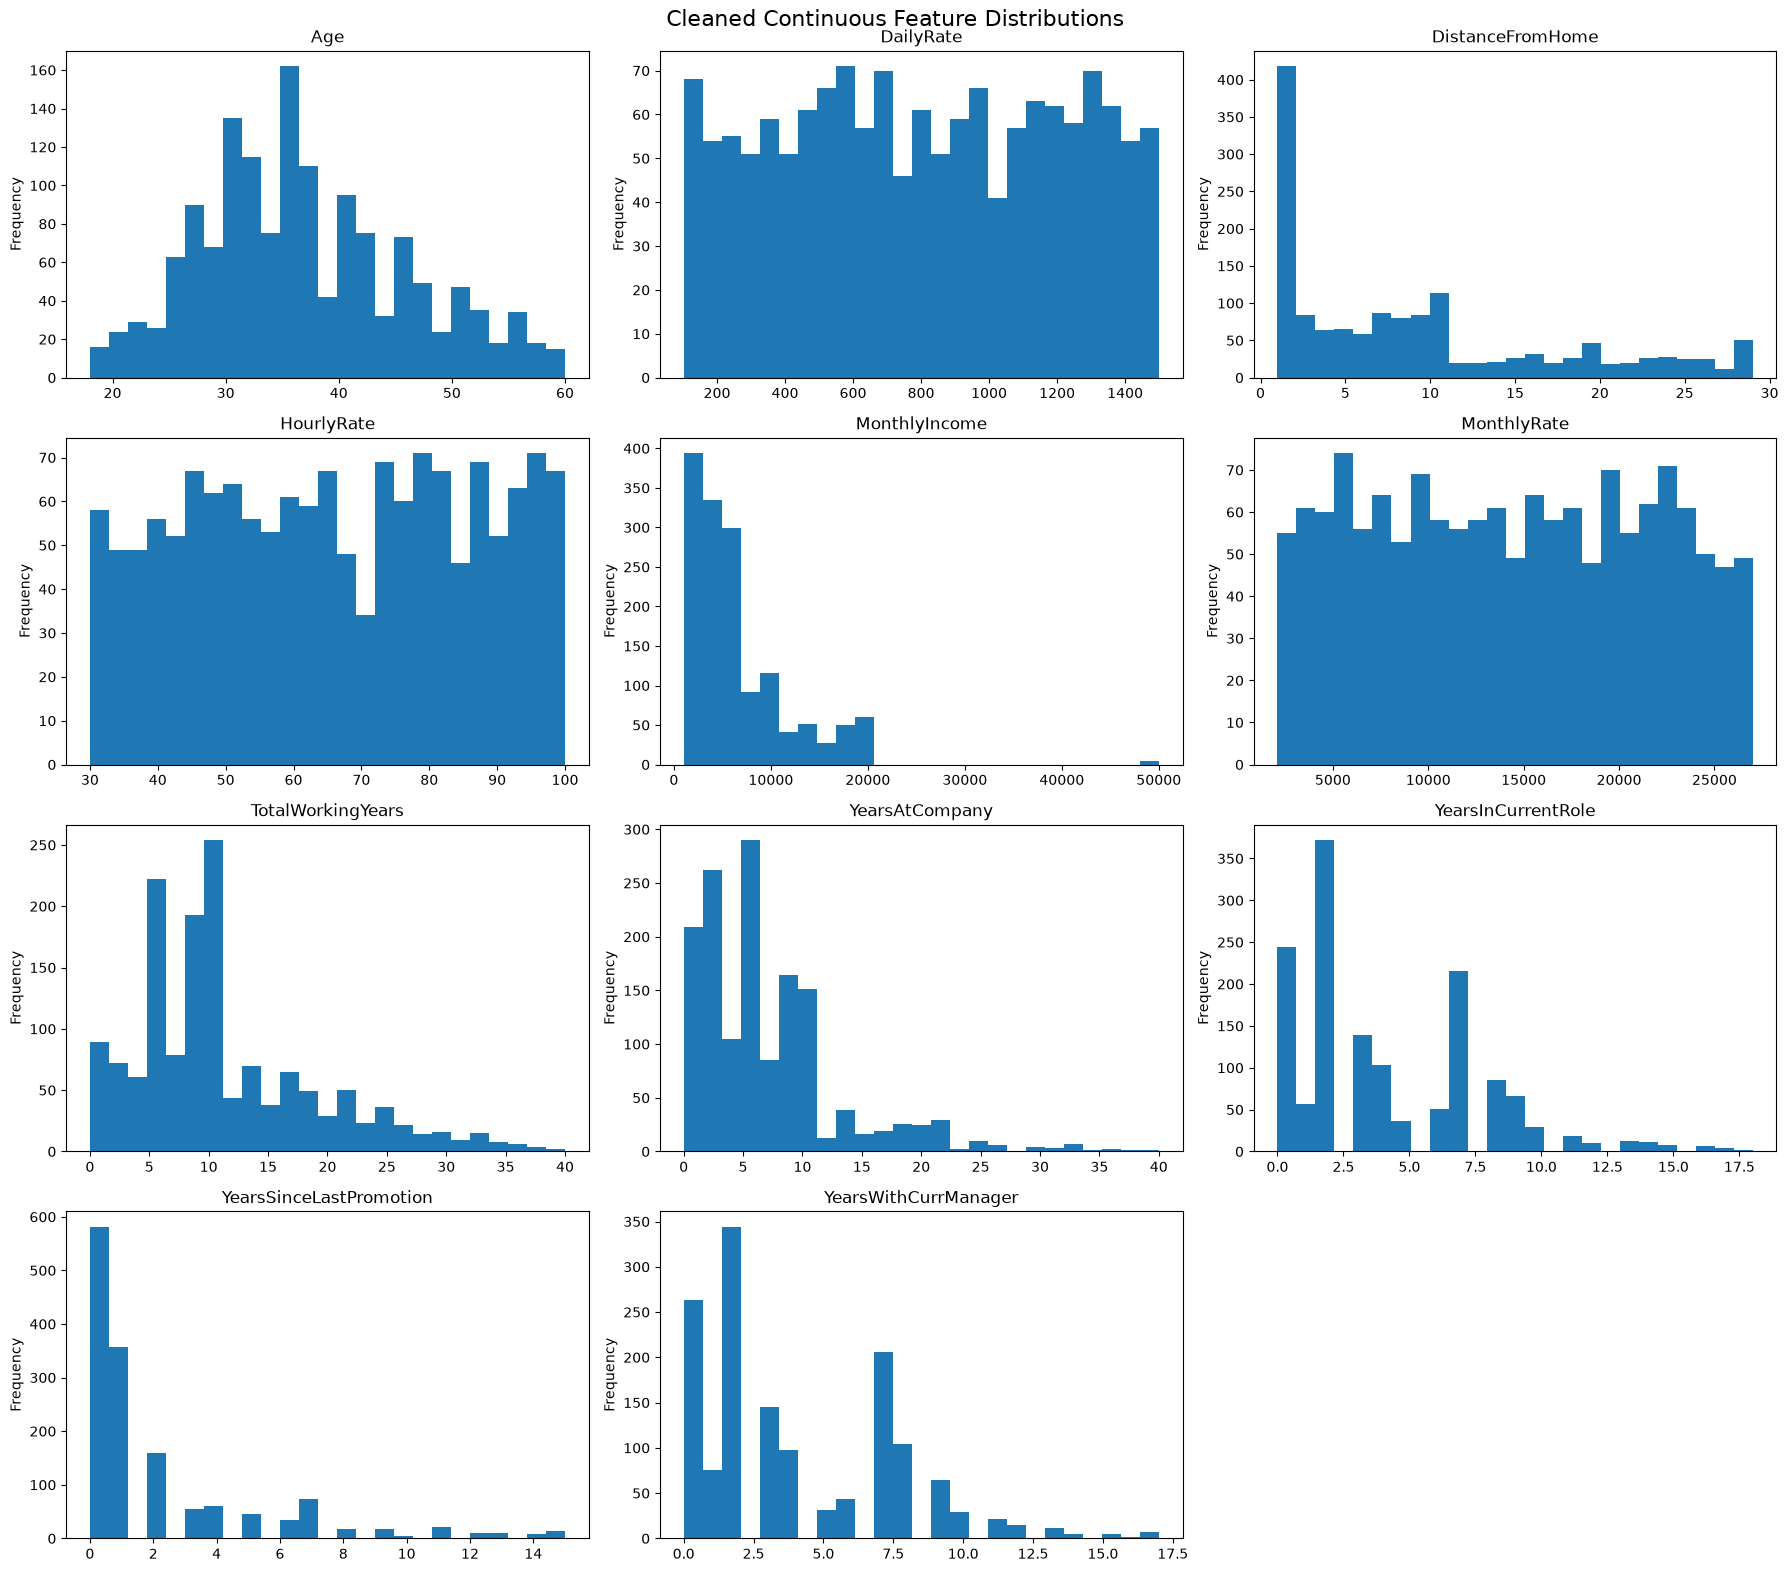

In [255]:
# Plot distributions of continuous features after cleaning
import math

n_columns = 3
n_rows = math.ceil(len(continuous_columns_clean) / n_columns)

fig, axes = plt.subplots(n_rows, n_columns, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, column in enumerate(continuous_columns_clean):
    axes[i].hist(df_clean[column].dropna(), bins=25)
    axes[i].set_title(column)
    axes[i].set_ylabel("Frequency")

for j in range(len(continuous_columns_clean), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Cleaned Continuous Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

C:\Users\soham\AppData\Local\Temp\ipykernel_21144\1137970452.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df_clean[column].dropna(), vert=True)
C:\Users\soham\AppData\Local\Temp\ipykernel_21144\1137970452.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df_clean[column].dropna(), vert=True)
C:\Users\soham\AppData\Local\Temp\ipykernel_21144\1137970452.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df_clean[column].dropna(), vert=True)
C:\Users\soham\AppData\Local\Temp\ipykernel_21144\1137970452.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be re

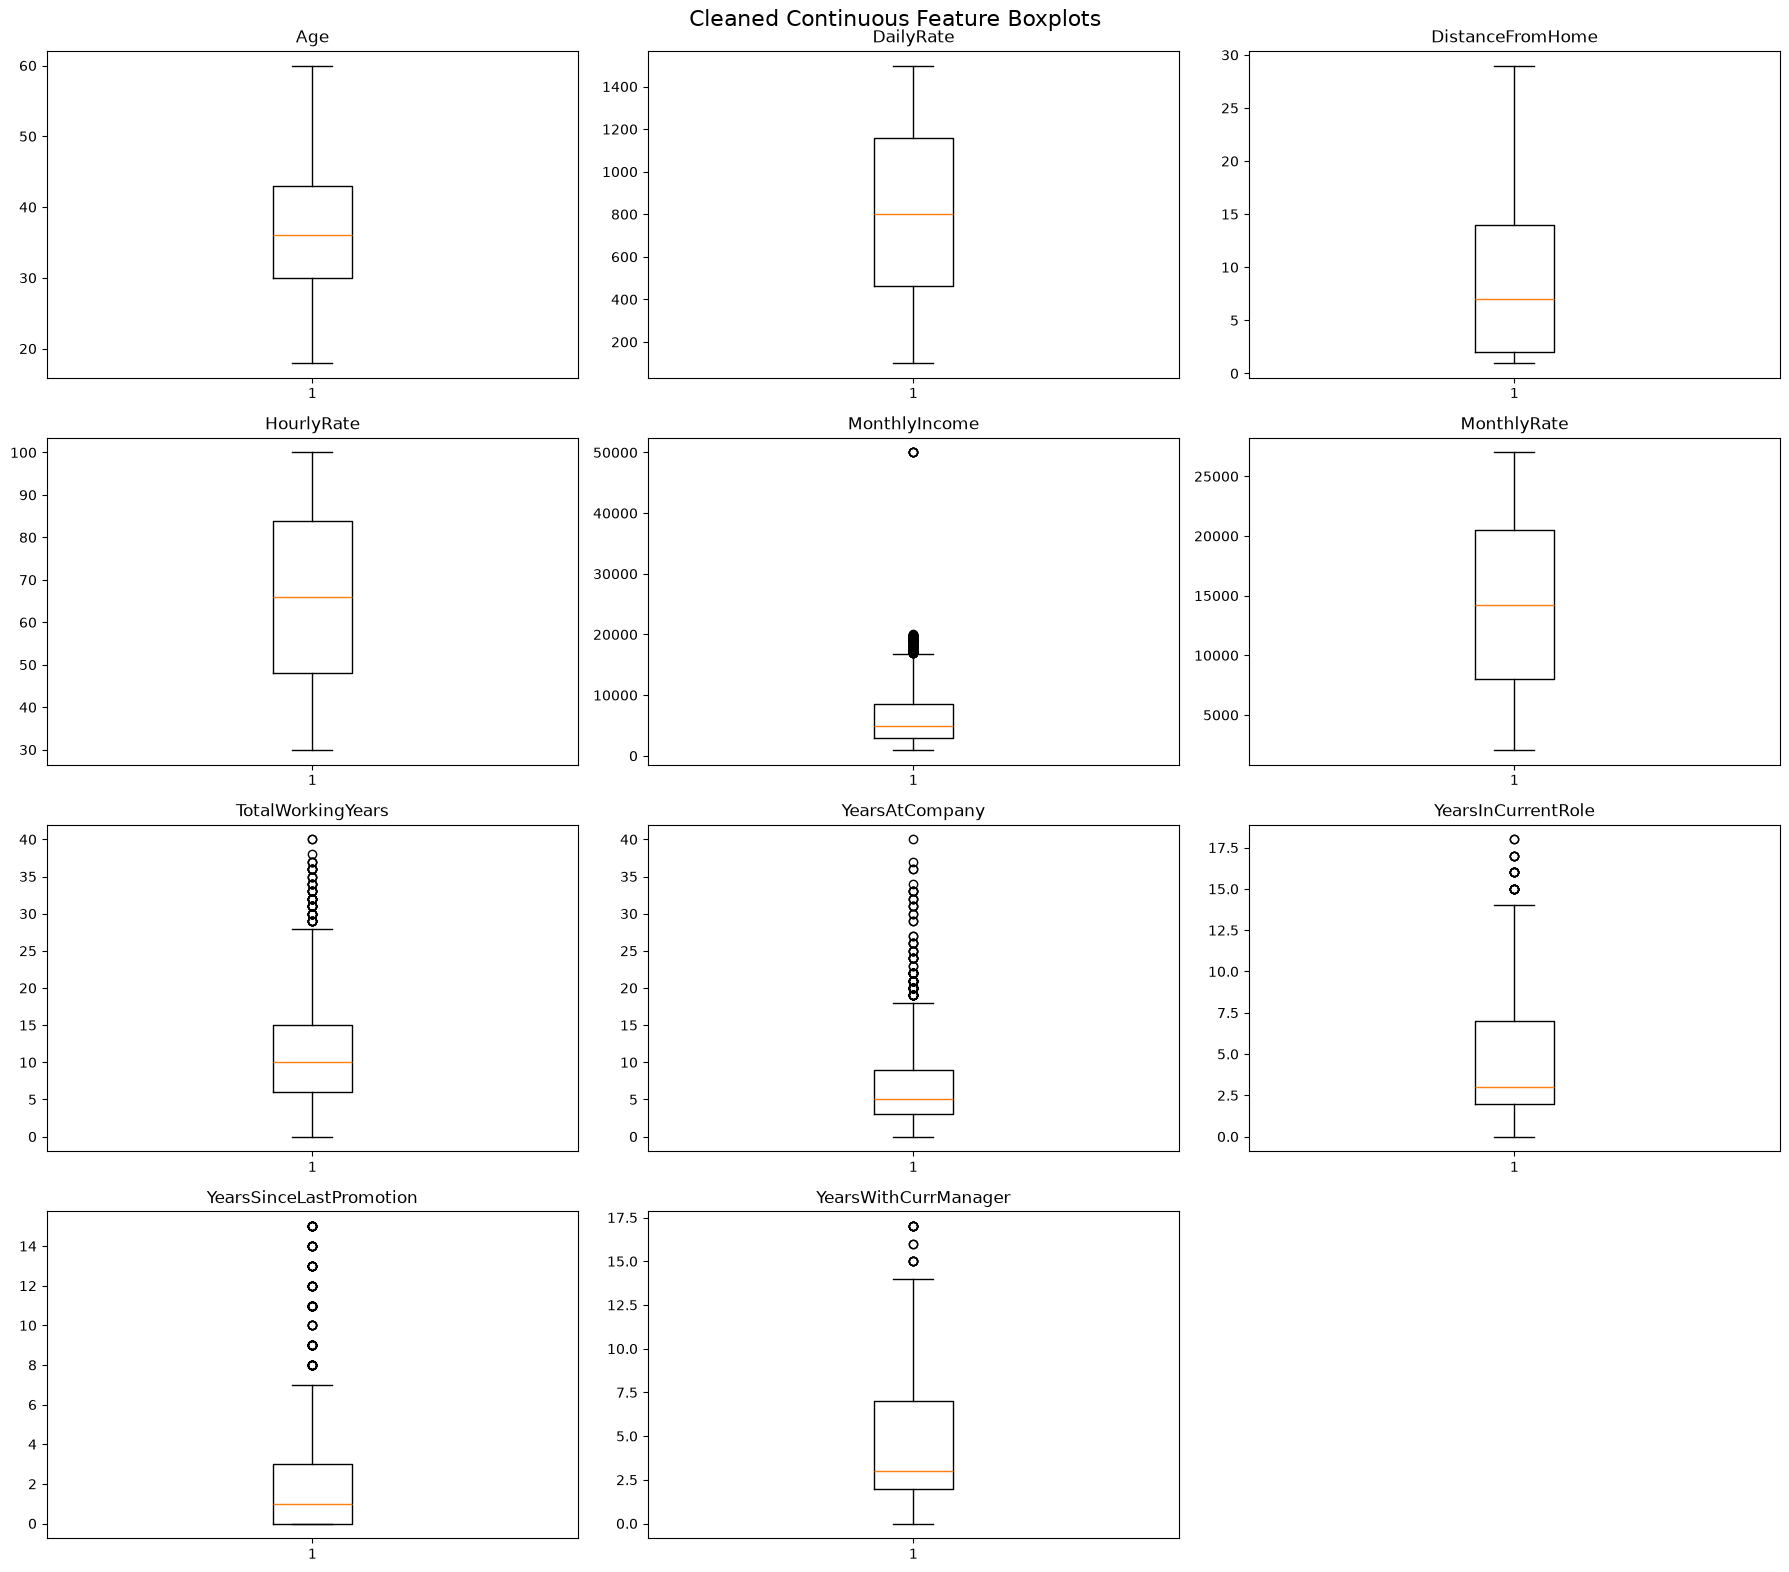

In [256]:
# Plot boxplots after cleaning
import math

n_columns = 3
n_rows = math.ceil(len(continuous_columns_clean) / n_columns)

fig, axes = plt.subplots(n_rows, n_columns, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, column in enumerate(continuous_columns_clean):
    axes[i].boxplot(df_clean[column].dropna(), vert=True)
    axes[i].set_title(column)

for j in range(len(continuous_columns_clean), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Cleaned Continuous Feature Boxplots", fontsize=16)
plt.tight_layout()
plt.show()

## 4.9 Remove Non-Informative Features

### Why Are We Removing These Features?

Some columns do not provide useful information for analysis.

- Constant features have the same value for every employee.
- Identifier columns uniquely identify employees but do not explain employee attrition.

Removing these features simplifies the dataset and improves the quality of the analysis.

In [257]:
# Remove constant and identifier columns
columns_to_drop = [
    "EmployeeCount",
    "Over18",
    "StandardHours",
    "EmployeeNumber",
    "RecordID"
]

df_clean.drop(
    columns=columns_to_drop,
    errors="ignore",
    inplace=True
)

print("Remaining columns:", df_clean.shape[1])

Remaining columns: 31


In [258]:
# Verify removed columns and inspect the final feature list
print(df_clean.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 4.10 Final Cleaning Validation

The final validation confirms that the cleaned dataset contains no duplicate rows, no missing values, no constant features, and no remaining violations of the defined business rules.

In [259]:
# Final validation summary
final_constant_features = [
    column for column in df_clean.columns
    if df_clean[column].nunique(dropna=False) == 1
]

print("Final Shape:", df_clean.shape)
print("Duplicate Rows:", df_clean.duplicated().sum())
print("Total Missing Values:", df_clean.isnull().sum().sum())
print("Constant Features:", final_constant_features)

assert df_clean.duplicated().sum() == 0
assert df_clean.isnull().sum().sum() == 0
assert len(final_constant_features) == 0

Final Shape: (1470, 31)
Duplicate Rows: 0
Total Missing Values: 0
Constant Features: []


In [260]:
# Save the cleaned dataset beside the notebook
clean_output_path = Path("C:\\Users\\soham\\Desktop\\ahmed\\NTI-ML\\Employee\\Data\\employee_attrition_clean.csv")
df_clean.to_csv(clean_output_path, index=False)

print(f"Clean dataset saved to: {clean_output_path.resolve()}")

Clean dataset saved to: C:\Users\soham\Desktop\ahmed\NTI-ML\Employee\Data\employee_attrition_clean.csv


# Phase 5 — Feature Preparation

The business analysis keeps readable labels and original measurement units. A numerical `AttritionFlag` is created to calculate attrition rates, and a reusable summary function is prepared for the EDA.

> Encoding and scaling are documented in **Appendix A** because they are needed for a model-ready dataset, not for interpreting the business charts.


## 5.1 EDA Preparation

`AttritionFlag` converts the target into a numerical indicator so that its mean represents the attrition rate. The helper function calculates employee count, employees who left, and attrition rate for any selected segment.


In [261]:
# Create a numerical attrition indicator for rate calculations
df_clean["AttritionFlag"] = df_clean["Attrition"].map({"No": 0, "Yes": 1})


def attrition_summary(data, column):
    """Return employee count, employees left, and attrition rate by group."""
    summary = (
        data.groupby(column, observed=False)["AttritionFlag"]
        .agg(
            EmployeeCount="size",
            EmployeesLeft="sum",
            AttritionRate="mean"
        )
        .reset_index()
    )

    summary["AttritionRate"] = summary["AttritionRate"] * 100
    return summary.sort_values("AttritionRate", ascending=False).reset_index(drop=True)


# Overall benchmark used when interpreting group-level rates
overall_attrition_rate = df_clean["AttritionFlag"].mean() * 100
print(f"Overall Attrition Rate: {overall_attrition_rate:.1f}%")

Overall Attrition Rate: 16.1%


# Phase 6 — End-to-End Exploratory Data Analysis (EDA)

Each business question follows the same analytical structure:

**Business Question → Hypothesis → Variables → Visualization → Pattern Analysis → Interpretation → Business Insight → Recommended Action**

> The findings describe associations observed in this dataset and do not prove causation.


## Business Question 1: Does Overtime Increase Employee Attrition?

### Business Question
Does overtime increase employee attrition?

### Hypothesis
Employees who work overtime have a higher attrition rate than employees who do not work overtime.

### Variables
- `OverTime`
- `Attrition`

### Visualization
A bar chart is appropriate because both variables are categorical and the objective is to compare attrition rates between overtime groups.

,OverTime,EmployeeCount,EmployeesLeft,AttritionRate
0,Yes,416,127,30.5
1,No,1054,110,10.4


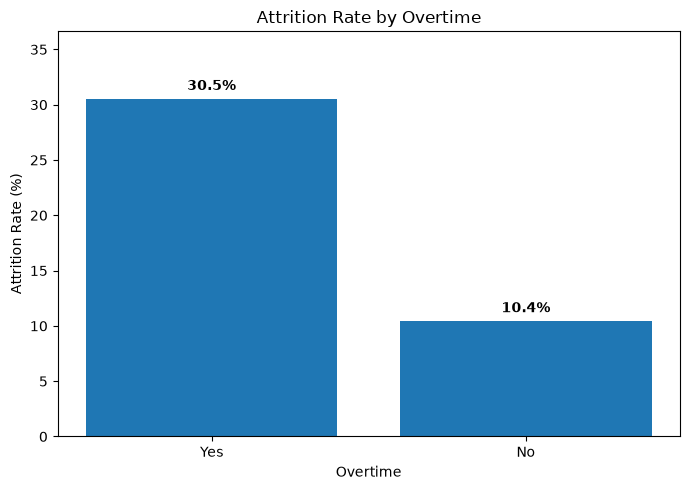

Overtime = Yes: 30.5%
Overtime = No:  10.4%
Relative risk: 2.9 times


In [262]:
overtime_summary = attrition_summary(
    df_clean,
    "OverTime"
)

display(overtime_summary.round({"AttritionRate": 1}))

plt.figure(figsize=(7, 5))
ax = plt.gca()
ax.bar(
    overtime_summary["OverTime"].astype(str),
    overtime_summary["AttritionRate"]
)

for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1f}%",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
        fontweight="bold"
    )

plt.title("Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, overtime_summary["AttritionRate"].max() * 1.2)
plt.tight_layout()
plt.show()

rate_yes = overtime_summary.loc[
    overtime_summary["OverTime"] == "Yes", "AttritionRate"
].iloc[0]
rate_no = overtime_summary.loc[
    overtime_summary["OverTime"] == "No", "AttritionRate"
].iloc[0]

print(f"Overtime = Yes: {rate_yes:.1f}%")
print(f"Overtime = No:  {rate_no:.1f}%")
print(f"Relative risk: {rate_yes / rate_no:.1f} times")

### Business Insight

Employees who work overtime have an attrition rate of approximately **30.5%**, compared with **10.4%** among employees who do not work overtime. Therefore, the overtime group leaves at almost three times the rate of the non-overtime group.

**بالعربي:** الموظفون الذين يعملون ساعات إضافية معدل تركهم للشركة يقارب ثلاثة أضعاف الموظفين الذين لا يعملون ساعات إضافية.

### Recommendation

Review workload distribution, introduce reasonable overtime limits, monitor burnout indicators, and identify departments and job roles that depend continuously on overtime.

## Business Question 2: Does Monthly Income Affect Attrition?

### Business Question
Does monthly income affect employee attrition?

### Hypothesis
Employees with lower monthly income are more likely to leave the company.

### Variables
- `MonthlyIncome`
- `Attrition`

### Visualization
A boxplot is appropriate because `MonthlyIncome` is numerical while `Attrition` is categorical. It allows comparison of the median, spread, and unusual income values between employees who stayed and employees who left.

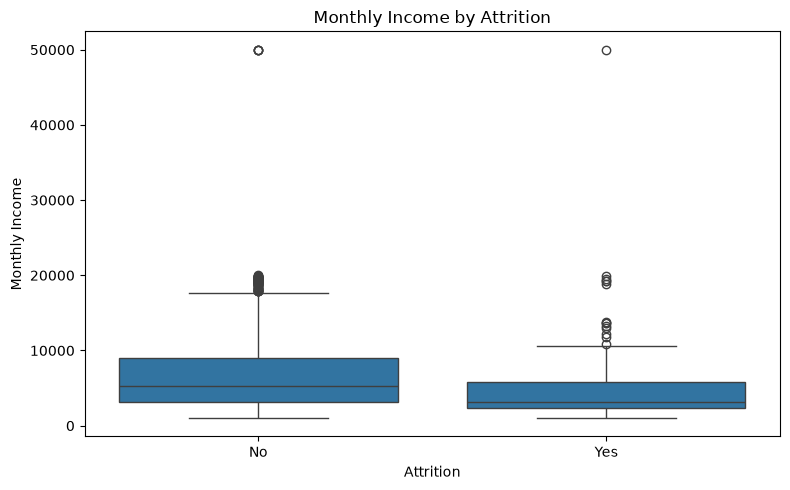

,mean,median,count
Attrition,,,
No,6972.2,5228.0,1233
Yes,4965.6,3172.0,237


,HighIncomeIndicator,EmployeeCount,EmployeesLeft,AttritionRate
0,Low Income,735,160,21.8
1,High Income,735,77,10.5


In [263]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clean,
    x="Attrition",
    y="MonthlyIncome",
    order=["No", "Yes"]
)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.tight_layout()
plt.show()

income_by_attrition = (
    df_clean.groupby("Attrition")["MonthlyIncome"]
    .agg(["mean", "median", "count"])
    .round(1)
)

display(income_by_attrition)

income_median = df_clean["MonthlyIncome"].median()
df_clean["HighIncomeIndicator"] = np.where(
    df_clean["MonthlyIncome"] >= income_median,
    "High Income",
    "Low Income"
)

income_group_summary = attrition_summary(
    df_clean,
    "HighIncomeIndicator"
)

display(income_group_summary.round({"AttritionRate": 1}))

### Business Insight

The median monthly income of employees who left is approximately **3,172**, compared with approximately **5,228** for employees who stayed. The low-income group also has an attrition rate of about **21.8%**, compared with about **10.5%** for the high-income group.

### Recommendation

Conduct a compensation review for lower-paid employees, especially employees at `JobLevel = 1` and employees in the early stages of their careers. Salary decisions should also consider performance, role, market benchmarks, and internal equity.

## Business Question 3: Which Department Has the Highest Attrition Rate?

### Business Question
Which department experiences the highest employee attrition rate?

### Hypothesis
Attrition rates differ across departments, with some departments experiencing higher turnover than the company average.

### Variables
- `Department`
- `Attrition`

### Visualization
A bar chart clearly compares the attrition rate across departments.

,Department,EmployeeCount,EmployeesLeft,AttritionRate
0,Sales,446,92,20.6
1,Human Resources,63,12,19.0
2,Research and Development,961,133,13.8


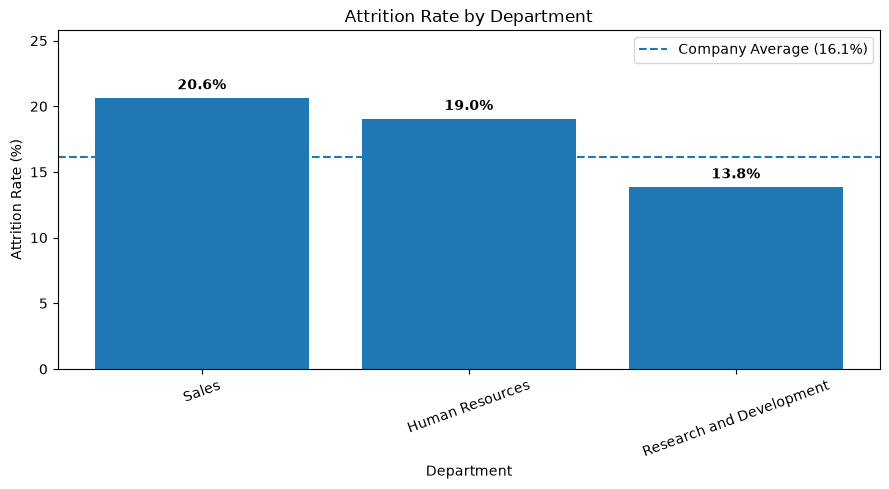

In [264]:
department_summary = attrition_summary(
    df_clean,
    "Department"
)

display(department_summary.round({"AttritionRate": 1}))

plt.figure(figsize=(9, 5))
ax = plt.gca()
ax.bar(
    department_summary["Department"].astype(str),
    department_summary["AttritionRate"]
)

for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1f}%",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
        fontweight="bold"
    )

plt.axhline(
    overall_attrition_rate,
    linestyle="--",
    label=f"Company Average ({overall_attrition_rate:.1f}%)"
)
plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=20)
plt.ylim(0, department_summary["AttritionRate"].max() * 1.25)
plt.legend()
plt.tight_layout()
plt.show()

### Business Insight

`Sales` has the highest attrition rate at approximately **20.6%**, followed by `Human Resources` at approximately **19.0%**. Both are above the company-wide attrition rate, while `Research and Development` is lower at approximately **13.8%**.

### Recommendation

Start targeted retention programs in Sales and Human Resources. Use stay interviews, manager reviews, workload analysis, and role-specific compensation analysis to understand the department-level causes.

## Business Question 4: Does Job Satisfaction Influence Attrition?

### Business Question
Does job satisfaction influence employee attrition?

### Hypothesis
Employees with lower job satisfaction have a higher attrition rate.

### Variables
- `JobSatisfaction`
- `Attrition`

### Visualization
A bar chart is used to compare attrition rates across the four satisfaction levels.

,JobSatisfaction,EmployeeCount,EmployeesLeft,AttritionRate
0,1,289,66,22.8
2,2,280,46,16.4
1,3,442,73,16.5
3,4,459,52,11.3


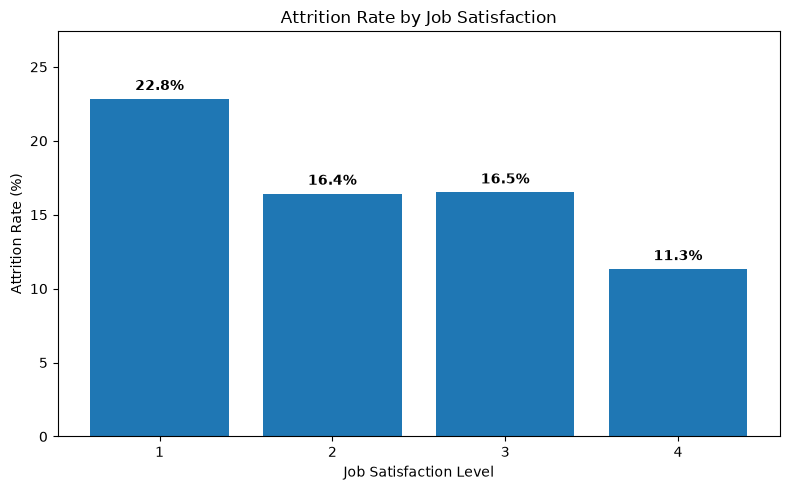

In [265]:
satisfaction_summary = attrition_summary(
    df_clean,
    "JobSatisfaction"
).sort_values("JobSatisfaction")

display(satisfaction_summary.round({"AttritionRate": 1}))

plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.bar(
    satisfaction_summary["JobSatisfaction"].astype(str),
    satisfaction_summary["AttritionRate"]
)

for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1f}%",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
        fontweight="bold"
    )

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, satisfaction_summary["AttritionRate"].max() * 1.2)
plt.tight_layout()
plt.show()

### Business Insight

Employees with the lowest job satisfaction level (`1`) have an attrition rate of approximately **22.8%**, while employees with the highest satisfaction level (`4`) have an attrition rate of approximately **11.3%**. The lowest-satisfaction employees therefore leave at about twice the rate of the highest-satisfaction employees.

### Recommendation

Use periodic engagement surveys and stay interviews to identify specific causes of dissatisfaction. Prioritize manager quality, recognition, workload, career development, and work environment improvements.

## Business Question 5: Does Business Travel Affect Attrition?

### Business Question
Does the frequency of business travel affect employee attrition?

### Hypothesis
Employees who travel frequently for business have a higher attrition rate than employees who travel rarely or do not travel.

### Variables
- `BusinessTravel`
- `Attrition`

### Visualization
A bar chart compares attrition rates across the travel-frequency categories.

,BusinessTravel,EmployeeCount,EmployeesLeft,AttritionRate
0,Travel_Frequently,277,69,24.9
1,Travel_Rarely,1043,156,15.0
2,Non-Travel,150,12,8.0


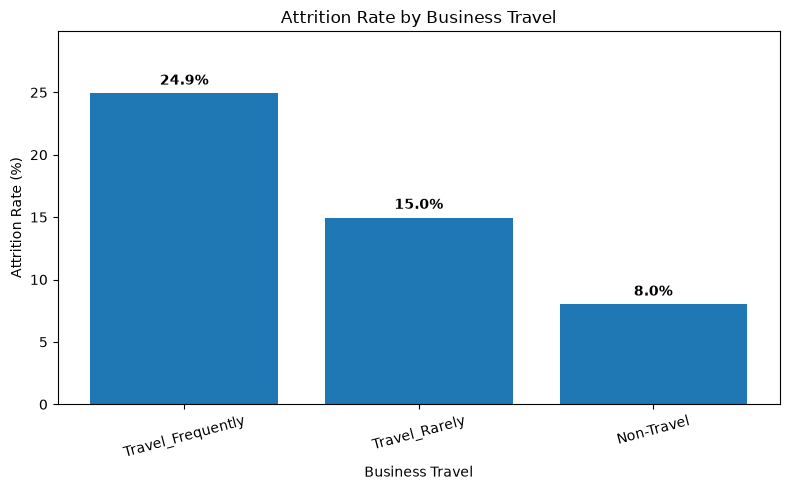

In [266]:
travel_summary = attrition_summary(
    df_clean,
    "BusinessTravel"
)

display(travel_summary.round({"AttritionRate": 1}))

plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.bar(
    travel_summary["BusinessTravel"].astype(str),
    travel_summary["AttritionRate"]
)

for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1f}%",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
        fontweight="bold"
    )

plt.title("Attrition Rate by Business Travel")
plt.xlabel("Business Travel")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=15)
plt.ylim(0, travel_summary["AttritionRate"].max() * 1.2)
plt.tight_layout()
plt.show()

### Business Insight

Employees who travel frequently have an attrition rate of approximately **24.9%**, compared with approximately **15.0%** among employees who travel rarely and **8.0%** among employees who do not travel.

### Recommendation

Consider travel allowances, better travel scheduling, recovery days, remote-work options where possible, and workload monitoring for frequent travelers.

## 6.6 Feature Engineering

The following features convert raw columns into business-friendly measures and employee segments. Each feature has a clear business rationale and supports the final high-risk analysis.


### 6.6.1 Income per Working Year

This feature normalizes monthly income by total experience. It can help identify employees whose income appears low relative to their years of experience.


In [267]:
df_clean["IncomePerWorkingYear"] = (
    df_clean["MonthlyIncome"]
    / df_clean["TotalWorkingYears"].clip(lower=1)
)

df_clean[["MonthlyIncome", "TotalWorkingYears", "IncomePerWorkingYear"]].head()

,MonthlyIncome,TotalWorkingYears,IncomePerWorkingYear
0,5473,8,684.125000
1,4772,10,477.200000
2,2090,7,298.571429
3,2909,8,363.625000
4,3468,6,578.000000


### 6.6.2 Experience Level

Employees are grouped into career-stage bands so attrition can be compared across meaningful experience segments rather than individual year values.


In [268]:
df_clean["ExperienceLevel"] = pd.cut(
    df_clean["TotalWorkingYears"],
    bins=[-1, 2, 7, 15, np.inf],
    labels=[
        "Entry",
        "Junior",
        "Mid",
        "Senior"
    ]
)

df_clean["ExperienceLevel"].value_counts(sort=False)

ExperienceLevel
Entry     119
Junior    404
Mid       599
Senior    348
Name: count, dtype: int64

### 6.6.3 Employee Tenure Groups

Tenure groups help distinguish new employees from established employees and reveal whether attrition risk changes across stages of the employee lifecycle.


In [269]:
df_clean["TenureGroup"] = pd.cut(
    df_clean["YearsAtCompany"],
    bins=[-1, 1, 3, 5, np.inf],
    labels=[
        "0-1 years",
        "2-3 years",
        "4-5 years",
        "6+ years"
    ]
)

df_clean["TenureGroup"].value_counts(sort=False)

TenureGroup
0-1 years    209
2-3 years    262
4-5 years    291
6+ years     708
Name: count, dtype: int64

### 6.6.4 High Income Indicator

Employees are split at the dataset median income to create a simple high-versus-low income comparison. This is a relative dataset-level segment, not an external market salary benchmark.


In [270]:
income_median = df_clean["MonthlyIncome"].median()

df_clean["HighIncomeIndicator"] = np.where(
    df_clean["MonthlyIncome"] >= income_median,
    "High Income",
    "Low Income"
)

print(f"Dataset Median Monthly Income: {income_median:,.1f}")
df_clean["HighIncomeIndicator"].value_counts()

Dataset Median Monthly Income: 4,955.0


HighIncomeIndicator
High Income    735
Low Income     735
Name: count, dtype: int64

### 6.6.5 Promotion Delay Ratio

The lecture proposes a promotion rate, but the dataset does not contain the number of promotions. Therefore, a true promotion rate cannot be calculated.

`PromotionDelayRatio` is used as a proxy. It measures years since the last promotion relative to years at the company. A higher value may indicate a longer promotion delay relative to tenure, but it should not be interpreted as the actual number or rate of promotions.


In [271]:
df_clean["PromotionDelayRatio"] = (
    df_clean["YearsSinceLastPromotion"]
    / df_clean["YearsAtCompany"].clip(lower=1)
)

df_clean[[
    "YearsSinceLastPromotion",
    "YearsAtCompany",
    "PromotionDelayRatio"
]].head()

,YearsSinceLastPromotion,YearsAtCompany,PromotionDelayRatio
0,0,6,0.0
1,1,10,0.1
2,0,0,0.0
3,3,3,1.0
4,2,2,1.0


### 6.6.6 Average Satisfaction

This feature summarizes four employee-experience measures into one average score:

- Environment Satisfaction
- Job Satisfaction
- Relationship Satisfaction
- Work-Life Balance


In [272]:
satisfaction_columns = [
    "EnvironmentSatisfaction",
    "JobSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance"
]

df_clean["AverageSatisfaction"] = (
    df_clean[satisfaction_columns].mean(axis=1)
)

df_clean[satisfaction_columns + ["AverageSatisfaction"]].head()

,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,AverageSatisfaction
0,2,4,1,1,2.00
1,3,2,4,3,3.00
2,4,3,2,3,3.00
3,4,3,3,3,3.25
4,1,2,4,3,2.50


## 6.7 Business Question 6: Which Employee Groups Are High Risk?

### Business Question
Which employee segments have the highest observed attrition rates?

### Hypothesis
New, entry-level, lower-income, single, frequently traveling, and overtime employees have higher attrition rates than their comparison groups.

### Variables
- `ExperienceLevel`
- `TenureGroup`
- `OverTime`
- `JobLevel`
- `MaritalStatus`
- `BusinessTravel`
- `HighIncomeIndicator`
- `Attrition`

### Interpretation Note
These groups describe **associations**, not proven causal effects. A person should not be classified as certain to leave simply because they belong to one segment.


,Employee Group,Employee Count,Employees Left,Attrition Rate
0,Entry Experience,119,52,43.7
1,0-1 Years at Company,209,74,35.4
2,Overtime Employees,416,127,30.5
3,Job Level 1,543,143,26.3
4,Single Employees,470,120,25.5
5,Frequent Travelers,277,69,24.9
6,Low Income Employees,735,160,21.8


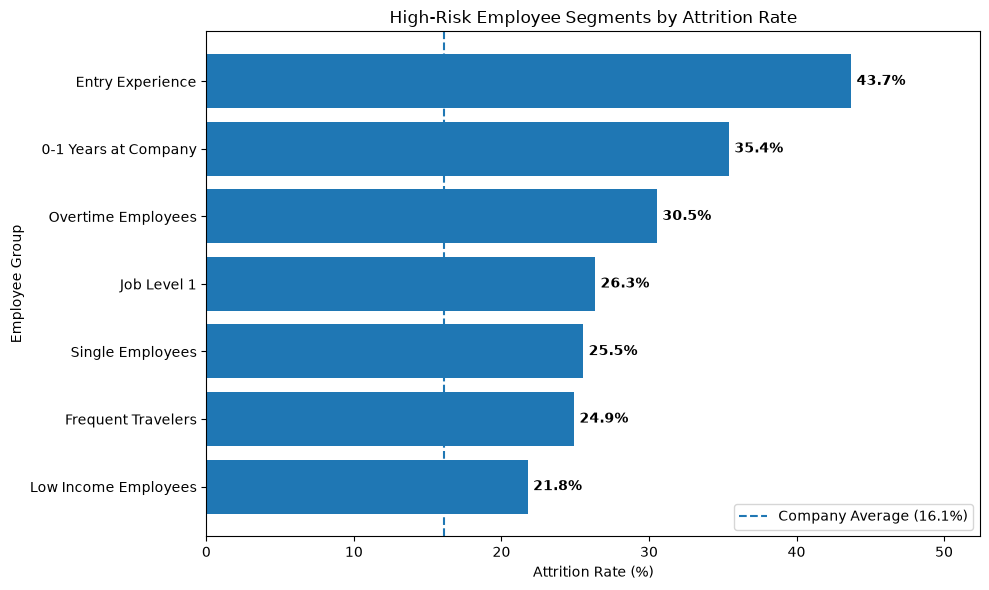

In [273]:
# Calculate selected high-risk segment rates dynamically
segment_specs = [
    ("Entry Experience", "ExperienceLevel", "Entry"),
    ("0-1 Years at Company", "TenureGroup", "0-1 years"),
    ("Overtime Employees", "OverTime", "Yes"),
    ("Job Level 1", "JobLevel", 1),
    ("Single Employees", "MaritalStatus", "Single"),
    ("Frequent Travelers", "BusinessTravel", "Travel_Frequently"),
    ("Low Income Employees", "HighIncomeIndicator", "Low Income")
]

high_risk_rows = []

for segment_name, column, value in segment_specs:
    segment_data = df_clean.loc[df_clean[column] == value]
    high_risk_rows.append({
        "Employee Group": segment_name,
        "Employee Count": len(segment_data),
        "Employees Left": int(segment_data["AttritionFlag"].sum()),
        "Attrition Rate": segment_data["AttritionFlag"].mean() * 100
    })

high_risk_summary = (
    pd.DataFrame(high_risk_rows)
    .sort_values("Attrition Rate", ascending=False)
    .reset_index(drop=True)
)

display(high_risk_summary.round({"Attrition Rate": 1}))

plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.barh(
    high_risk_summary["Employee Group"].astype(str),
    high_risk_summary["Attrition Rate"]
)
ax.invert_yaxis()

for bar in ax.patches:
    ax.annotate(
        f"{bar.get_width():.1f}%",
        (bar.get_width(), bar.get_y() + bar.get_height() / 2),
        va="center",
        ha="left",
        xytext=(4, 0),
        textcoords="offset points",
        fontweight="bold"
    )

plt.axvline(
    overall_attrition_rate,
    linestyle="--",
    label=f"Company Average ({overall_attrition_rate:.1f}%)"
)
plt.title("High-Risk Employee Segments by Attrition Rate")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Employee Group")
plt.xlim(0, high_risk_summary["Attrition Rate"].max() * 1.2)
plt.legend()
plt.tight_layout()
plt.show()

### High-Risk Profile

The strongest observed high-risk profile is generally an employee who is:

- New to the company
- At an entry or low job level
- In the lower-income segment
- Working overtime
- Traveling frequently
- Experiencing low job satisfaction

The strongest individual group in this analysis is the `Entry` experience group, followed by employees with `0-1 years` at the company. This suggests that early-career and early-tenure retention should be a major HR priority.

### Recommended Business Actions

1. Introduce a structured 30/60/90-day onboarding and retention program.
2. Review overtime and workload for entry-level and new employees.
3. Review compensation and career paths for `JobLevel = 1` employees.
4. Conduct stay interviews with frequent travelers and low-satisfaction employees.
5. Track these segments monthly in an HR retention dashboard.

## 6.8 Interpret Findings

This section converts the statistical outputs and visual patterns into clear business meaning. Interpretation focuses on the size of each difference, the employee groups affected, and the practical HR implications.

> **Caution:** The findings describe associations in this dataset. They do not prove that any single factor directly causes an employee to leave.


In [274]:
# Create a consolidated findings table from the analysis results
interpretation_findings = pd.DataFrame([
    {
        "Business Question": "Does overtime increase attrition?",
        "Observed Finding": "30.5% attrition with overtime vs 10.4% without overtime",
        "Interpretation": "Employees working overtime leave at almost three times the rate of employees who do not work overtime."
    },
    {
        "Business Question": "Does monthly income affect attrition?",
        "Observed Finding": "Median income: 3,172 for leavers vs 5,228 for stayers",
        "Interpretation": "Employees who leave tend to be concentrated in lower-income groups, indicating a compensation-related retention risk."
    },
    {
        "Business Question": "Which department has the highest attrition?",
        "Observed Finding": "Sales 20.6%, Human Resources 19.0%, R&D 13.8%",
        "Interpretation": "Sales and Human Resources require targeted investigation because their attrition rates exceed the company average."
    },
    {
        "Business Question": "Does job satisfaction influence attrition?",
        "Observed Finding": "22.8% at satisfaction level 1 vs 11.3% at level 4",
        "Interpretation": "Low-satisfaction employees leave at about twice the rate of highly satisfied employees."
    },
    {
        "Business Question": "Does business travel affect attrition?",
        "Observed Finding": "Frequent travel 24.9%, rare travel 15.0%, non-travel 8.0%",
        "Interpretation": "Attrition rises as travel frequency increases, suggesting travel burden may be linked to employee turnover."
    },
    {
        "Business Question": "Which employee groups are high risk?",
        "Observed Finding": "Entry experience 43.7% and 0-1 year tenure 35.4%",
        "Interpretation": "Early-career and newly hired employees represent the strongest observed retention risk."
    }
])

display(interpretation_findings)


,Business Question,Observed Finding,Interpretation
0,Does overtime increase attrition?,30.5% attrition with overtime vs 10.4% without overtime,Employees working overtime leave at almost three times the rate of employees who do not work overtime.
1,Does monthly income affect attrition?,"Median income: 3,172 for leavers vs 5,228 for stayers","Employees who leave tend to be concentrated in lower-income groups, indicating a compensation-related retention risk."
2,Which department has the highest attrition?,"Sales 20.6%, Human Resources 19.0%, R&D 13.8%",Sales and Human Resources require targeted investigation because their attrition rates exceed the company average.
3,Does job satisfaction influence attrition?,22.8% at satisfaction level 1 vs 11.3% at level 4,Low-satisfaction employees leave at about twice the rate of highly satisfied employees.
4,Does business travel affect attrition?,"Frequent travel 24.9%, rare travel 15.0%, non-travel 8.0%","Attrition rises as travel frequency increases, suggesting travel burden may be linked to employee turnover."
5,Which employee groups are high risk?,Entry experience 43.7% and 0-1 year tenure 35.4%,Early-career and newly hired employees represent the strongest observed retention risk.


### 6.8.1 Interpretation of the Main Patterns

1. **Workload pressure is strongly associated with attrition.** The overtime gap is the largest directly comparable difference among the main operational variables.
2. **Compensation matters most for lower-paid employees.** Salary competitiveness should be assessed by role and job level rather than through a single company-wide adjustment.
3. **Attrition is not evenly distributed across departments.** Sales and Human Resources have higher observed rates and may face different root causes.
4. **Employee experience affects retention.** Low job satisfaction, frequent travel, and early tenure are consistently linked with higher attrition.
5. **The first stage of employment is critical.** Entry-level employees and employees in their first year have the highest observed risk, making onboarding and early support major priorities.


## 6.9 Extract Business Insights

Business insights combine related findings into a smaller number of decision-relevant conclusions.


In [275]:
business_insights = pd.DataFrame([
    {
        "Priority": 1,
        "Business Insight": "Overtime is the strongest operational risk signal.",
        "Evidence": "30.5% attrition with overtime vs 10.4% without overtime",
        "Business Meaning": "Persistent overtime may reflect understaffing, workload imbalance, burnout, or weak work-life balance."
    },
    {
        "Priority": 2,
        "Business Insight": "New and entry-level employees are the highest-risk groups.",
        "Evidence": "43.7% attrition for Entry experience and 35.4% for 0-1 year tenure",
        "Business Meaning": "The company may be losing employees before they become fully productive, increasing replacement and training costs."
    },
    {
        "Priority": 3,
        "Business Insight": "Lower income is associated with higher attrition.",
        "Evidence": "21.8% attrition for low-income employees vs 10.5% for high-income employees",
        "Business Meaning": "Compensation may be less competitive for selected roles, levels, or career stages."
    },
    {
        "Priority": 4,
        "Business Insight": "Sales and Human Resources require department-specific retention plans.",
        "Evidence": "Sales 20.6% and Human Resources 19.0%, both above the 16.1% company rate",
        "Business Meaning": "A single company-wide retention program may not address department-specific causes."
    },
    {
        "Priority": 5,
        "Business Insight": "Employee experience factors are linked to turnover.",
        "Evidence": "Low satisfaction 22.8%; frequent travel 24.9%; single employees 25.5%",
        "Business Meaning": "Retention depends on more than salary and should include workload, travel, management, and engagement interventions."
    }
]).sort_values("Priority")

display(business_insights)


,Priority,Business Insight,Evidence,Business Meaning
0,1,Overtime is the strongest operational risk signal.,30.5% attrition with overtime vs 10.4% without overtime,"Persistent overtime may reflect understaffing, workload imbalance, burnout, or weak work-life balance."
1,2,New and entry-level employees are the highest-risk groups.,43.7% attrition for Entry experience and 35.4% for 0-1 year tenure,"The company may be losing employees before they become fully productive, increasing replacement and training costs."
2,3,Lower income is associated with higher attrition.,21.8% attrition for low-income employees vs 10.5% for high-income employees,"Compensation may be less competitive for selected roles, levels, or career stages."
3,4,Sales and Human Resources require department-specific retention plans.,"Sales 20.6% and Human Resources 19.0%, both above the 16.1% company rate",A single company-wide retention program may not address department-specific causes.
4,5,Employee experience factors are linked to turnover.,Low satisfaction 22.8%; frequent travel 24.9%; single employees 25.5%,"Retention depends on more than salary and should include workload, travel, management, and engagement interventions."


## 6.10 Business Recommendations

The recommendations below are tied directly to the findings and organized by priority. Management should initially test them through focused pilot programs before a company-wide rollout.


In [276]:
recommendation_plan = pd.DataFrame([
    {
        "Priority": "Critical",
        "Recommended Action": "Review overtime and workload distribution",
        "Target Group": "Employees working overtime; high-overtime departments and roles",
        "Suggested KPI": "Overtime hours, overtime attrition rate, workload balance, absenteeism",
        "Suggested Timing": "Start within 30 days"
    },
    {
        "Priority": "Critical",
        "Recommended Action": "Launch a first-year retention and onboarding program",
        "Target Group": "Entry-level employees and employees with 0-1 year tenure",
        "Suggested KPI": "30/60/90-day retention, first-year attrition, onboarding satisfaction",
        "Suggested Timing": "Pilot within 60 days"
    },
    {
        "Priority": "High",
        "Recommended Action": "Conduct role- and level-based compensation reviews",
        "Target Group": "Low-income employees, especially Job Level 1",
        "Suggested KPI": "Pay-position ratio, attrition by salary band, offer acceptance rate",
        "Suggested Timing": "Complete within one compensation cycle"
    },
    {
        "Priority": "High",
        "Recommended Action": "Create targeted retention plans for Sales and Human Resources",
        "Target Group": "Sales and Human Resources employees",
        "Suggested KPI": "Department attrition, manager effectiveness, engagement scores",
        "Suggested Timing": "Diagnose within 45 days"
    },
    {
        "Priority": "Medium",
        "Recommended Action": "Improve employee listening and satisfaction monitoring",
        "Target Group": "Employees with low satisfaction scores",
        "Suggested KPI": "Job satisfaction, pulse survey response, stay-interview themes",
        "Suggested Timing": "Quarterly monitoring"
    },
    {
        "Priority": "Medium",
        "Recommended Action": "Reduce the burden of frequent business travel",
        "Target Group": "Frequent travelers",
        "Suggested KPI": "Travel frequency, traveler attrition, recovery days, travel satisfaction",
        "Suggested Timing": "Policy review within 90 days"
    }
])

display(recommendation_plan)


,Priority,Recommended Action,Target Group,Suggested KPI,Suggested Timing
0,Critical,Review overtime and workload distribution,Employees working overtime; high-overtime departments and roles,"Overtime hours, overtime attrition rate, workload balance, absenteeism",Start within 30 days
1,Critical,Launch a first-year retention and onboarding program,Entry-level employees and employees with 0-1 year tenure,"30/60/90-day retention, first-year attrition, onboarding satisfaction",Pilot within 60 days
2,High,Conduct role- and level-based compensation reviews,"Low-income employees, especially Job Level 1","Pay-position ratio, attrition by salary band, offer acceptance rate",Complete within one compensation cycle
3,High,Create targeted retention plans for Sales and Human Resources,Sales and Human Resources employees,"Department attrition, manager effectiveness, engagement scores",Diagnose within 45 days
4,Medium,Improve employee listening and satisfaction monitoring,Employees with low satisfaction scores,"Job satisfaction, pulse survey response, stay-interview themes",Quarterly monitoring
5,Medium,Reduce the burden of frequent business travel,Frequent travelers,"Travel frequency, traveler attrition, recovery days, travel satisfaction",Policy review within 90 days


### 6.10.1 Recommended Management Actions

- Establish an **overtime threshold alert** and require managers to justify repeated overtime.
- Conduct structured **30-, 60-, and 90-day check-ins** for new employees.
- Run **stay interviews** with high-risk employees before they decide to leave.
- Review salaries using **job role, job level, experience, and performance**, not only the overall company median.
- Build a monthly HR dashboard showing attrition by department, tenure, income group, overtime, travel, and satisfaction.
- Evaluate interventions using pre-defined KPIs and compare results with a suitable control or pre-pilot baseline.


# Phase 7 — Executive Summary

## Business Problem

IBM HR management is seeking to understand employee turnover and identify practical opportunities to improve retention. The analysis examined **1,470 employee records** after correcting duplicates, missing values, inconsistent categories, invalid values, and non-informative features. The overall attrition rate is approximately **16.1%**, representing **237 employees** who left the company.

## Key Findings

- Employees working overtime have an attrition rate of approximately **30.5%**, compared with **10.4%** among employees who do not work overtime.
- The `Entry` experience group records approximately **43.7%** attrition, while employees with `0–1 year` at the company record approximately **35.4%**.
- Lower-income employees have approximately **21.8%** attrition compared with **10.5%** among higher-income employees.
- `Sales` and `Human Resources` have the highest departmental attrition rates.
- Low job satisfaction and frequent business travel are also associated with higher turnover.

## Business Recommendations

1. Introduce overtime controls and rebalance workload.
2. Launch a structured first-year onboarding and retention program.
3. Conduct targeted compensation reviews by job role and job level.
4. Develop department-specific retention plans for Sales and Human Resources.
5. Use stay interviews, pulse surveys, and improved travel support to address employee-experience risks.

## Expected Business Impact

The proposed actions are expected to reduce avoidable turnover, lower recruitment and onboarding costs, improve workforce stability, and retain new employees long enough to reach full productivity. Management should begin with focused pilot programs, monitor monthly KPIs, and evaluate results over a three-to-six-month period.


# Phase 8 — Final Business Report

## 8.1 Business Problem & Objectives

Management has observed employee turnover and needs to understand the characteristics associated with attrition. The objectives were to measure the size of the problem, identify high-risk employee groups, evaluate workload, compensation, satisfaction, travel, department, experience, and tenure patterns, and translate the findings into practical HR actions.

## 8.2 Data Overview

- **Final analyzed records:** 1,470 employees
- **Target variable:** `Attrition` (`Yes` or `No`)
- **Main feature groups:** demographics, job role and level, compensation, satisfaction, travel, overtime, experience, tenure, promotion history, and work-life balance
- **Overall attrition:** 237 employees, or approximately 16.1%

## 8.3 Data Quality Summary

The dataset was assessed for missing values, duplicate records, duplicate IDs, incorrect data types, inconsistent categories, invalid values, outliers, constant features, and high-missing columns. Exact duplicate records were removed, text values were standardized, and clearly invalid ages, incomes, distances, and experience relationships were converted to missing values before appropriate group-median imputation. `ManagerNotes` was removed because of its high missing percentage. Constant and identifier features were excluded from the business analysis. Final validation confirmed zero duplicate records and zero remaining missing values.

## 8.4 EDA Findings

| Analysis Area | Main Finding | Interpretation |
|---|---|---|
| Overtime | 30.5% attrition with overtime vs 10.4% without | Overtime employees leave at almost three times the rate |
| Monthly Income | Median 3,172 for leavers vs 5,228 for stayers | Lower-paid employees show greater retention risk |
| Department | Sales 20.6%; HR 19.0%; R&D 13.8% | Sales and HR require targeted diagnosis |
| Job Satisfaction | 22.8% at level 1 vs 11.3% at level 4 | Low satisfaction is linked to approximately double the attrition |
| Business Travel | Frequent 24.9%; Rare 15.0%; Non-travel 8.0% | Greater travel frequency is associated with higher attrition |
| High-Risk Groups | Entry 43.7%; 0–1 year tenure 35.4% | Early-career and early-tenure employees are the top priority |

## 8.5 Engineered Features

The analysis created `IncomePerWorkingYear`, `ExperienceLevel`, `TenureGroup`, `HighIncomeIndicator`, `PromotionDelayRatio`, and `AverageSatisfaction`. These features convert raw columns into business-friendly employee segments and measures that improve interpretation and high-risk profiling.

## 8.6 Business Insights

1. Overtime is the strongest operational signal associated with attrition.
2. New and entry-level employees face the greatest observed retention risk.
3. Lower income is linked with approximately twice the attrition of higher income.
4. Sales and Human Resources have above-average department attrition.
5. Satisfaction and travel patterns demonstrate that non-compensation factors also influence retention risk.
6. The observed relationships are associations and should be investigated further before being treated as causal.

## 8.7 Business Recommendations

1. Control repeated overtime and rebalance workloads.
2. Launch a structured first-year employee retention program.
3. Review compensation by role, level, experience, and performance.
4. Develop department-specific retention plans for Sales and Human Resources.
5. Conduct regular pulse surveys and stay interviews.
6. Review frequent-travel policies, allowances, scheduling, and recovery support.
7. Monitor interventions through a monthly attrition dashboard with clear KPIs.

## 8.8 Executive Summary

The analysis found that employee attrition is concentrated in identifiable groups rather than distributed evenly across the workforce. Overtime, early tenure, entry-level experience, lower income, department, job satisfaction, and frequent travel are the strongest observed risk signals. Management should prioritize workload controls, first-year retention, targeted compensation reviews, department-specific interventions, employee listening, and travel support. These actions are expected to reduce avoidable turnover, lower replacement costs, improve workforce stability, and strengthen the employee experience. Because the analysis identifies association rather than causation, interventions should be tested through focused pilots and evaluated using monthly retention KPIs.


In [277]:
# Final project completion summary
overall_attrition = df_clean["AttritionFlag"].mean() * 100
employees_left = int(df_clean["AttritionFlag"].sum())

completion_summary = pd.DataFrame({
    "Deliverable": [
        "Clean Dataset",
        "Analysis Notebook",
        "Engineered Features",
        "Business Insights",
        "Business Recommendations",
        "Executive Summary",
        "Final Business Report"
    ],
    "Status": ["Completed"] * 7
})

print(f"Analyzed employees: {len(df_clean):,}")
print(f"Employees who left: {employees_left:,}")
print(f"Overall attrition rate: {overall_attrition:.1f}%")
display(completion_summary)


Analyzed employees: 1,470
Employees who left: 237
Overall attrition rate: 16.1%


,Deliverable,Status
0,Clean Dataset,Completed
1,Analysis Notebook,Completed
2,Engineered Features,Completed
3,Business Insights,Completed
4,Business Recommendations,Completed
5,Executive Summary,Completed
6,Final Business Report,Completed


# Appendix A — Encoding and Scaling

Encoding and scaling are not required for the business charts because EDA should preserve readable labels and original units. They are included here to prepare an optional model-ready dataset after the business analysis and engineered features have been completed.


## A.1 Encoding

- The target `Attrition` is mapped from `No/Yes` to `0/1`.
- Categorical predictors are converted using one-hot encoding.
- `drop_first=True` removes one reference category from each categorical feature.


In [278]:
model_df = df_clean.copy()

model_df["Attrition"] = (
    model_df["Attrition"]
    .map({"No": 0, "Yes": 1})
)

# AttritionFlag duplicates the encoded target and is removed.
model_df = model_df.drop(columns=["AttritionFlag"], errors="ignore")

categorical_columns = (
    model_df.select_dtypes(
        include=["object", "category"]
    ).columns
)

model_df = pd.get_dummies(
    model_df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Model-ready shape after encoding:", model_df.shape)
model_df.head()

Model-ready shape after encoding: (1470, 57)


C:\Users\soham\AppData\Local\Temp\ipykernel_21144\4096634782.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  model_df.select_dtypes(


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,IncomePerWorkingYear,PromotionDelayRatio,AverageSatisfaction,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research and Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,EducationField_Unknown,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,JobRole_Unknown,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,HighIncomeIndicator_Low Income,ExperienceLevel_Junior,ExperienceLevel_Mid,ExperienceLevel_Senior,TenureGroup_2-3 years,TenureGroup_4-5 years,TenureGroup_6+ years
0,41,1,1102,1,2,2,94,3,2,4,5473,19479,8,11,3,1,0,8,0,1,6,4,0,5,684.125000,0.0,2.00,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0,0,1
1,49,0,279,8,1,3,61,2,2,2,4772,24907,1,23,4,4,1,10,3,3,10,7,1,7,477.200000,0.1,3.00,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1
2,37,1,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,298.571429,0.0,3.00,0,1,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0
3,33,0,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,3,3,3,0,363.625000,1.0,3.25,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,0,1,0,1,0,0
4,27,0,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,578.000000,1.0,2.50,0,1,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0


## A.2 Scaling

`StandardScaler` transforms selected continuous numerical features so that each has approximately zero mean and unit standard deviation. Binary, ordinal rating, and one-hot encoded columns are left unchanged.


In [279]:
from sklearn.preprocessing import StandardScaler

scale_columns = [
    "Age",
    "MonthlyIncome",
    "DailyRate",
    "HourlyRate",
    "DistanceFromHome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "IncomePerWorkingYear",
    "PromotionDelayRatio",
    "AverageSatisfaction"
]

# Keep only columns that exist in the model dataset.
scale_columns = [
    column for column in scale_columns
    if column in model_df.columns
]

scaler = StandardScaler()
model_df[scale_columns] = scaler.fit_transform(
    model_df[scale_columns]
)

print("Scaled Columns:", scale_columns)
display(model_df[scale_columns].describe().T.round(3))

Scaled Columns: ['Age', 'MonthlyIncome', 'DailyRate', 'HourlyRate', 'DistanceFromHome', 'TotalWorkingYears', 'YearsAtCompany', 'IncomePerWorkingYear', 'PromotionDelayRatio', 'AverageSatisfaction']


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,-0.0,1.0,-2.094,-0.768,-0.104,0.670,2.549
MonthlyIncome,1470.0,0.0,1.0,-1.057,-0.710,-0.318,0.339,8.127
DailyRate,1470.0,0.0,1.0,-1.737,-0.837,-0.001,0.879,1.727
HourlyRate,1470.0,0.0,1.0,-1.766,-0.880,0.005,0.879,1.678
DistanceFromHome,1470.0,-0.0,1.0,-1.011,-0.888,-0.271,0.593,2.445
TotalWorkingYears,1470.0,-0.0,1.0,-1.456,-0.679,-0.160,0.488,3.727
YearsAtCompany,1470.0,-0.0,1.0,-1.149,-0.655,-0.325,0.334,5.441
IncomePerWorkingYear,1470.0,0.0,1.0,-0.765,-0.388,-0.175,0.118,29.024
PromotionDelayRatio,1470.0,0.0,1.0,-0.855,-0.855,-0.366,0.613,2.081
AverageSatisfaction,1470.0,-0.0,1.0,-3.423,-0.457,0.038,0.532,2.510


## A.3 Save Prepared Datasets

The business-ready dataset preserves readable categories and engineered features. The model-ready dataset contains encoded and scaled features for optional future machine-learning work.


In [280]:
# Save the updated business-ready and model-ready datasets
business_ready_path = Path("C:\\Users\\soham\\Desktop\\ahmed\\NTI-ML\\Employee\\Data\\employee_attrition_business_ready.csv")
model_ready_path = Path("C:\\Users\\soham\\Desktop\\ahmed\\NTI-ML\\Employee\\Data\\employee_attrition_model_ready.csv")

df_clean.to_csv(business_ready_path, index=False)
model_df.to_csv(model_ready_path, index=False)

print(f"Business-ready dataset saved to: {business_ready_path.resolve()}")
print(f"Model-ready dataset saved to: {model_ready_path.resolve()}")
print("Business-ready shape:", df_clean.shape)
print("Model-ready shape:", model_df.shape)

Business-ready dataset saved to: C:\Users\soham\Desktop\ahmed\NTI-ML\Employee\Data\employee_attrition_business_ready.csv
Model-ready dataset saved to: C:\Users\soham\Desktop\ahmed\NTI-ML\Employee\Data\employee_attrition_model_ready.csv
Business-ready shape: (1470, 38)
Model-ready shape: (1470, 57)
